In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))

warnings.filterwarnings('ignore', category=UserWarning, module='seaborn')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

from monitorviz.io import load_collection
from monitorviz.transforms import RunCollection
from monitorviz.viz import (
    setup_style, correlation_heatmap, pareto_panel_multi,
    phase_breakdown_stacked, throttling_heatmap,
    hw_distributions_panel, temp_freq_dual,
    cpu_memory_dual_phases,
)
setup_style()

DATA_BASE = Path('../data/tfg-data')
EXP_FAN   = DATA_BASE / 'E0-FAN'
EXP_NOFAN = DATA_BASE / 'E0-NOFAN'

_runs_fan_all   = load_collection(EXP_FAN).runs   if EXP_FAN.exists()   else []
_runs_nofan_all = load_collection(EXP_NOFAN).runs if EXP_NOFAN.exists() else []

ENGINE = 'LLAMA'
runs_fan   = [r for r in _runs_fan_all   if r.summary.inference_engine == ENGINE]
runs_nofan = [r for r in _runs_nofan_all if r.summary.inference_engine == ENGINE]

coll = RunCollection(runs_fan + runs_nofan)

summary = coll.summary_df()
hw_df   = coll.hw_metrics_df()
pm_df   = coll.prompt_metrics_df()

print(f'Engine: {ENGINE}')
print(f'Runs cargados: {len(coll.runs)}')
print(f'  · Con ventilador:    {len(runs_fan)}')
print(f'  · Sin ventilador:    {len(runs_nofan)}')
print(f'  · Runs en summary:   {len(summary)}')
n_valid = len(pm_df[~pm_df["is_empty_generation"]]) if not pm_df.empty else 0
print(f'  · Prompts válidos:   {n_valid}')

# Añadir config_label = "modelo\n(FAN/NOFAN)" para gráficas
if not summary.empty:
    summary["config_label"] = (
        summary["model_label"] + "\n(" +
        summary["fan"].map({True: "FAN", False: "NOFAN"}) + ")"
    )
    _cl = summary[["run_id", "config_label"]]
    if not hw_df.empty:
        hw_df = hw_df.merge(_cl, on="run_id", how="left")
    if not pm_df.empty:
        pm_df = pm_df.merge(_cl, on="run_id", how="left")

# ── Agregados HW por run (solo durante inferencia activa: cpu > 10%) ──────────

# 1. Frecuencia media de CPU durante inferencia
if not hw_df.empty and "freq_mean_ghz" in hw_df.columns:
    freq_agg = (
        hw_df[hw_df["cpu_usage_pct"] > 10]
        .groupby("run_id")["freq_mean_ghz"]
        .mean()
        .rename("freq_mean_inference_ghz")
        .reset_index()
    )
    summary = summary.merge(freq_agg, on="run_id", how="left")

# 2. Fan speed media durante inferencia
FAN_COL = "fan_rpm"   # nombre en hw_df (mapeado desde fan_speed_ en _parsers.py)

if not hw_df.empty and FAN_COL in hw_df.columns:
    fan_agg = (
        hw_df[hw_df["cpu_usage_pct"] > 10]
        .groupby("run_id")[FAN_COL]
        .mean()
        .rename("fan_speed_mean")
        .reset_index()
    )
    summary = summary.merge(fan_agg, on="run_id", how="left")
    print(f"fan_speed_mean añadida: {summary['fan_speed_mean'].notna().sum()} runs con datos")
else:
    print(f"Columna fan no encontrada. Disponibles: "
          f"{[c for c in hw_df.columns if 'fan' in c.lower()]}")

# 3. Número real de parámetros (entero exacto, sin abreviar)
if "n_params" not in summary.columns:
    run_map_p = {r.run_id: r for r in coll.runs}
    summary["n_params"] = [
        (run_map_p[rid].summary.model_info or {}).get("n_params", float("nan"))
        if rid in run_map_p else float("nan")
        for rid in summary["run_id"]
    ]

# Verificación rápida de las nuevas columnas
_check_cols = ["freq_mean_inference_ghz", "fan_speed_mean", "n_params"]
print(summary[[c for c in _check_cols if c in summary.columns]
              + ["model_label", "fan"]].round(4))


tokenProb size mismatch in run=1780948937859414717 prompt=7: got 266 tokens, eval_count=-1


Engine: LLAMA
Runs cargados: 12
  · Con ventilador:    6
  · Sin ventilador:    6
  · Runs en summary:   12
  · Prompts válidos:   178
fan_speed_mean añadida: 12 runs con datos
    freq_mean_inference_ghz  fan_speed_mean    n_params           model_label    fan
0                    2.4000       7383.4430  3429006336         ministral (L)   True
1                    2.4000       7424.1816  3212749888      Llama-3.2-3B (L)   True
2                    2.4000       7229.8031  1235814432      Llama-3.2-1B (L)   True
3                    2.4000       7182.4896  3191396096           granite (L)   True
4                    2.4000       7267.6001  4458122848             gemma (L)   True
5                    2.4000       7491.2552  1777088000  DeepSeek-R1-1.5B (L)   True
6                    1.0497          0.0000  3429006336         ministral (L)  False
7                    1.0842          0.0000  3212749888      Llama-3.2-3B (L)  False
8                    1.0854          0.0000  1235814432   

1# E0 — Comparativa baseline entre modelos

## Pregunta de investigación
¿Qué modelo LLM ofrece el mejor compromiso rendimiento/eficiencia en
una Raspberry Pi 5 en condiciones de inferencia estándar?
¿Cómo afecta la refrigeración activa (ventilador) al rendimiento sostenido?

## Hipótesis
- Los modelos más pequeños (1B) serán más rápidos pero con menor calidad.
- El ventilador reducirá el throttling térmico y mejorará el throughput sostenido.
- La potencia media será similar entre modelos (limitada por el SoC),
  pero la energía por token variará según la velocidad de cada modelo.

## Configuración del experimento
| Parámetro       | Valor fijo                                          |
|-----------------|-----------------------------------------------------|
| batch_size      | 512                                                 |
| context_size    | 2048                                                |
| quantization    | Q4_K_M                                              |
| temperature     | 0.7                                                 |
| num_prompts     | 15 (IFEval)                                         |
| hardware        | Raspberry Pi 5 (BCM2712, 8 GB LPDDR4X)             |

| Variable        | Valores                                             |
|-----------------|-----------------------------------------------------|
| modelo          | Ministral-3B, Llama3.2-1B, Llama3.2-3B,           |
|                 | DeepSeek-Qwen-1.5B, Gemma3n-e2b                    |
| refrigeración   | Con ventilador (FAN) / Sin ventilador (NOFAN)       |

## 1. Validación de datos

In [2]:
if not summary.empty:
    _cols = [c for c in ['model_label', 'fan', 'engine',
                          'n_prompts', 'n_empty_generations', 'throttled_ratio']
             if c in summary.columns]
    display(summary[_cols].sort_values(['model_label', 'fan']).reset_index(drop=True))

    # Matriz del experimento: modelos × fan
    if 'tokens_per_s_mean' in summary.columns:
        matrix = summary.pivot_table(
            index='model_label', columns='fan',
            values='tokens_per_s_mean', aggfunc='count'
        ).fillna(0).astype(int)
        print('\nRuns por modelo × refrigeración (count):')
        display(matrix)

    alertas = summary[
        (summary.get('n_empty_generations', pd.Series(0, index=summary.index)) > 0) |
        (summary.get('throttled_ratio', pd.Series(0.0, index=summary.index)) > 0.8)
    ]
    if not alertas.empty:
        print('\n⚠️ Alertas:')
        _acols = [c for c in ['model_label', 'fan', 'n_empty_generations', 'throttled_ratio']
                  if c in alertas.columns]
        display(alertas[_acols])
    else:
        print('\n✅ Sin alertas.')
else:
    print('Sin datos cargados.')


,model_label,fan,engine,n_prompts,n_empty_generations,throttled_ratio
0,DeepSeek-R1-1.5B (L),False,LLAMA,15,0,0.999750
1,DeepSeek-R1-1.5B (L),True,LLAMA,15,0,0.000000
2,Llama-3.2-1B (L),False,LLAMA,15,0,0.998837
3,Llama-3.2-1B (L),True,LLAMA,15,0,0.000000
4,Llama-3.2-3B (L),False,LLAMA,15,0,0.999479
5,Llama-3.2-3B (L),True,LLAMA,15,0,0.000000
6,gemma (L),False,LLAMA,15,0,0.997967
7,gemma (L),True,LLAMA,15,0,0.000000
8,granite (L),False,LLAMA,15,0,0.997107
9,granite (L),True,LLAMA,15,0,0.000000



Runs por modelo × refrigeración (count):


fan,False,True
model_label,,
DeepSeek-R1-1.5B (L),1,1
Llama-3.2-1B (L),1,1
Llama-3.2-3B (L),1,1
gemma (L),1,1
granite (L),1,1
ministral (L),1,1



⚠️ Alertas:


,model_label,fan,n_empty_generations,throttled_ratio
0,ministral (L),True,1,0.000000
6,ministral (L),False,1,0.998979
7,Llama-3.2-3B (L),False,0,0.999479
8,Llama-3.2-1B (L),False,0,0.998837
9,granite (L),False,0,0.997107
10,gemma (L),False,0,0.997967
11,DeepSeek-R1-1.5B (L),False,0,0.999750


## 2. Evolución temporal del hardware

Timelines de temperatura, potencia y swap durante el run completo,
agrupados por modelo y refrigeración. Permiten identificar el momento
en que aparece el throttling térmico y su evolución.

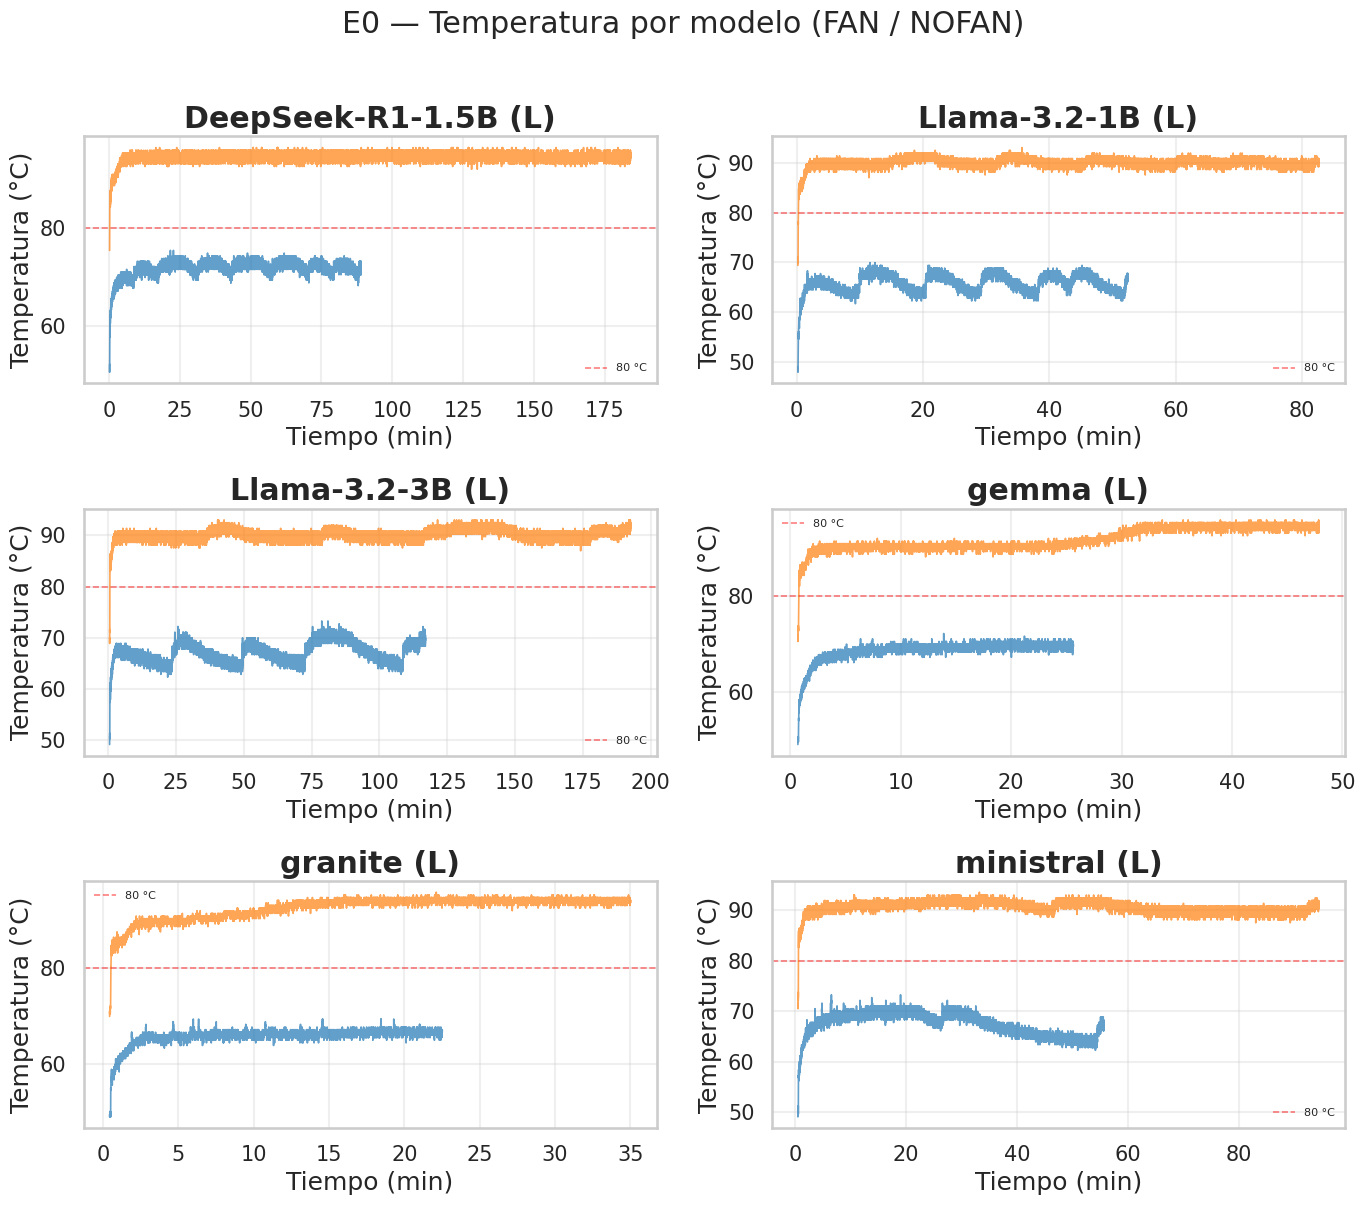

In [3]:
def _plot_timeline(hw_data, y_col, ylabel, suptitle, hline=None):
    models = sorted(hw_data['model_label'].unique())
    if not models:
        print(f'Sin datos para {suptitle}')
        return
    ncols = 2
    nrows = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        sub = hw_data[hw_data['model_label'] == model]
        if sub.empty:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        t_max = sub['t_rel_s'].max()
        x_vals = sub['t_rel_s'] / 60 if t_max > 1800 else sub['t_rel_s']
        ax.set_xlabel('Tiempo (min)' if t_max > 1800 else 'Tiempo (s)')
        for rid in sub['run_id'].unique():
            s = sub[sub['run_id'] == rid].sort_values('t_rel_s')
            xv = s['t_rel_s'] / 60 if t_max > 1800 else s['t_rel_s']
            ax.plot(xv.values, s[y_col].values, alpha=0.7, lw=1.2)
        if hline is not None:
            ax.axhline(hline, ls='--', color='red', alpha=0.5, lw=1.2,
                       label=f'{hline} °C')
            ax.legend(fontsize=8)
        ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight='bold')
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_df.empty:
    _plot_timeline(hw_df, 'temperature_c', 'Temperatura (°C)',
                   'E0 — Temperatura por modelo (FAN / NOFAN)', hline=80)
else:
    print('Sin datos de hardware para timelines de temperatura.')


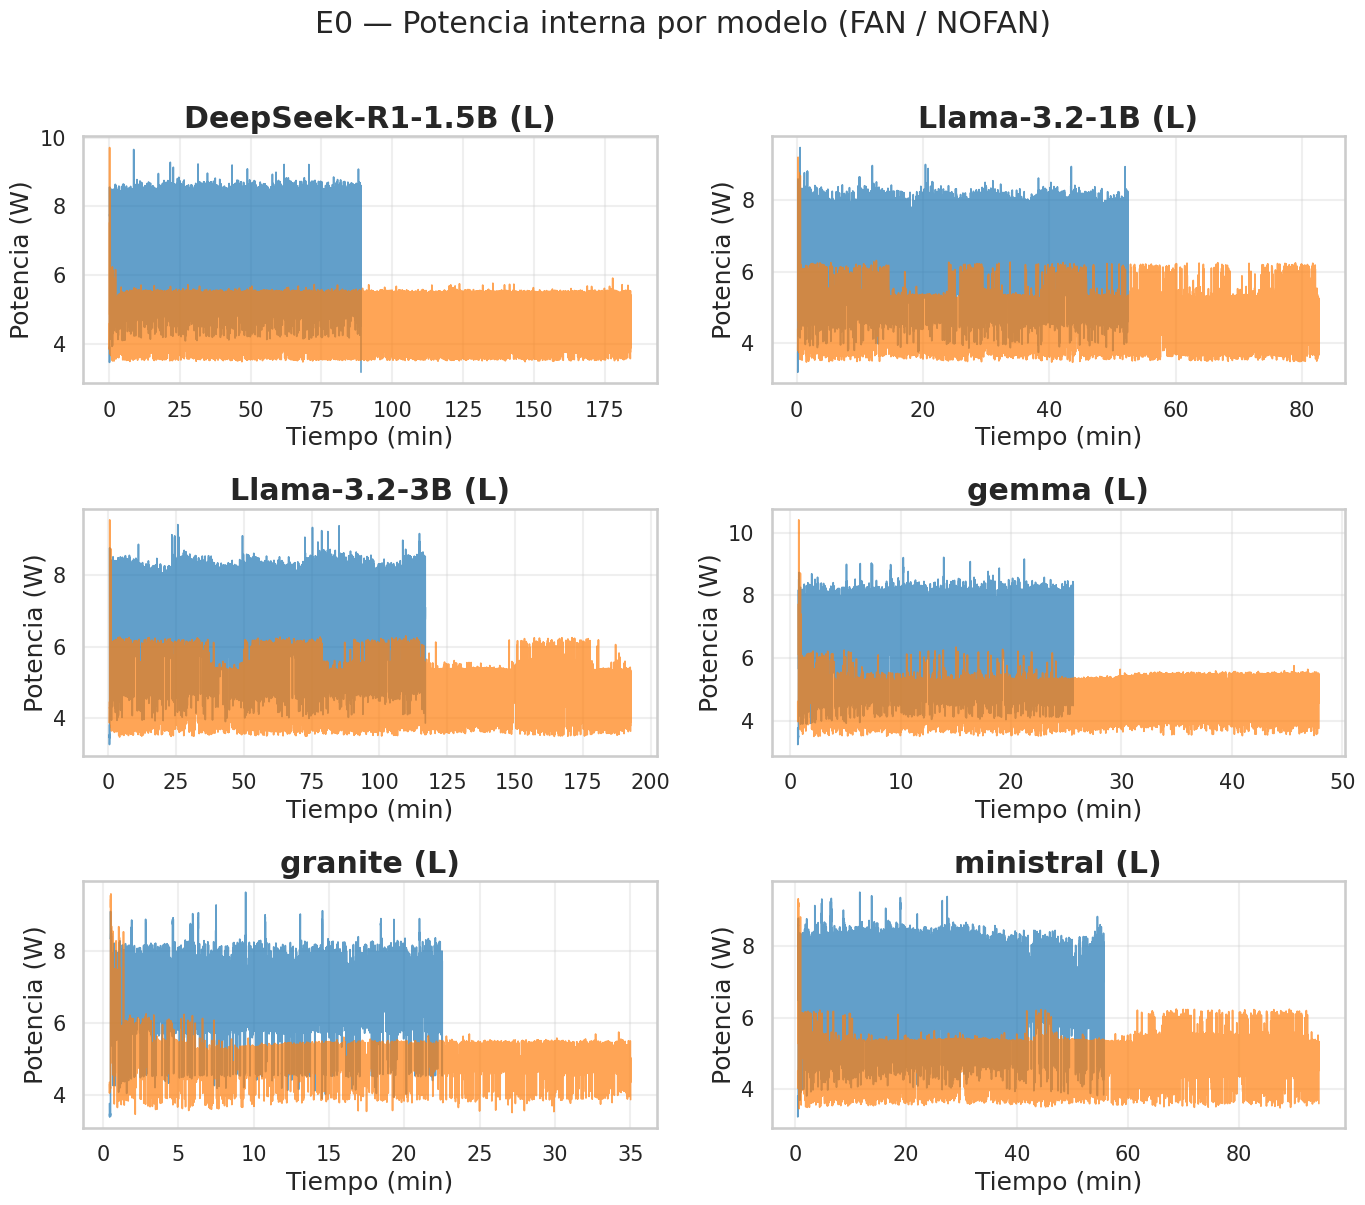

In [4]:
if not hw_df.empty:
    _plot_timeline(hw_df, 'internal_power_w', 'Potencia (W)',
                   'E0 — Potencia interna por modelo (FAN / NOFAN)')
else:
    print('Sin datos de hardware para timelines de potencia.')


Run representativo (más throttleado): DeepSeek-R1-Distill-Qwen-1.5B-Q4_K_M


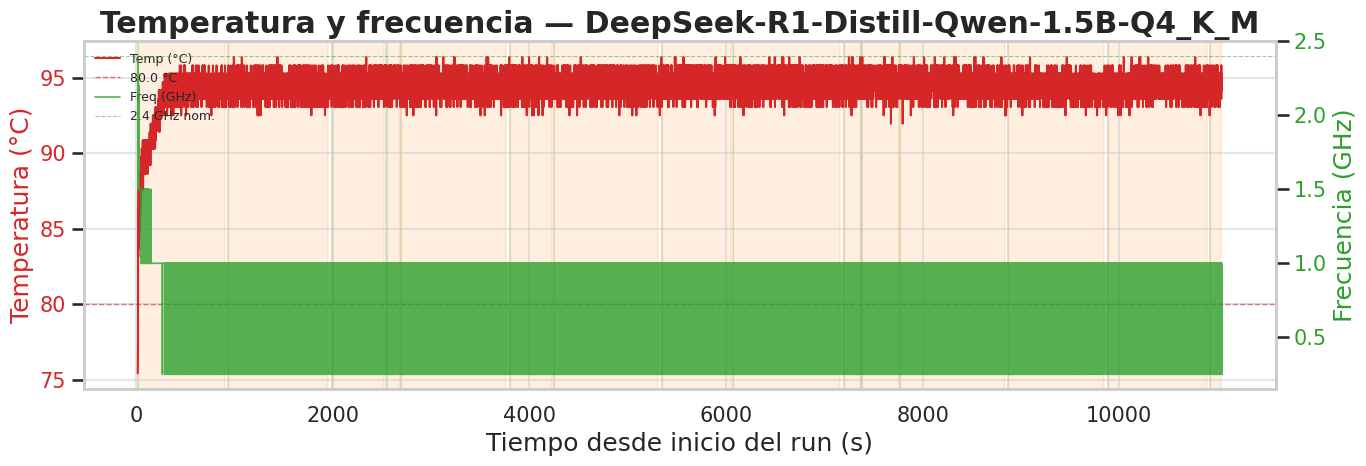

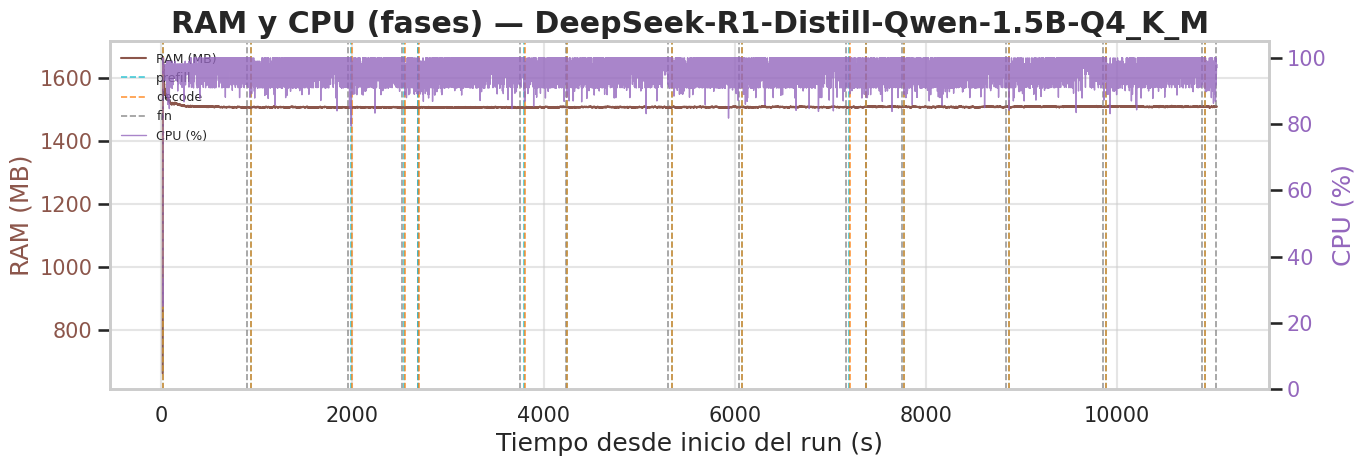

In [5]:
if not hw_df.empty and not summary.empty and 'throttled_ratio' in summary.columns:
    _best = summary.sort_values('throttled_ratio', ascending=False)
    _rep_id = _best['run_id'].iloc[0] if 'run_id' in _best.columns else None
    if _rep_id:
        run_rep = next((r for r in coll.runs if r.run_id == _rep_id), None)
        hw_rep  = hw_df[hw_df['run_id'] == _rep_id]
        if run_rep is not None and not hw_rep.empty:
            print(f'Run representativo (más throttleado): {run_rep.model_short}')
            try:
                fig = temp_freq_dual(hw_rep, run_rep)
                plt.show()
            except Exception as e:
                print(f'temp_freq_dual: {e}')
            try:
                fig = cpu_memory_dual_phases(hw_rep, run_rep)
                plt.show()
            except Exception as e:
                print(f'cpu_memory_dual_phases: {e}')
        else:
            print('Run representativo no encontrado.')
    else:
        print('Sin run_id disponible.')
else:
    print('Sin datos de hardware o throttled_ratio para run representativo.')


## 3. Distribuciones del entorno hardware

Distribuciones estadísticas de las métricas de hardware agregando todas
las muestras de todos los runs del experimento.

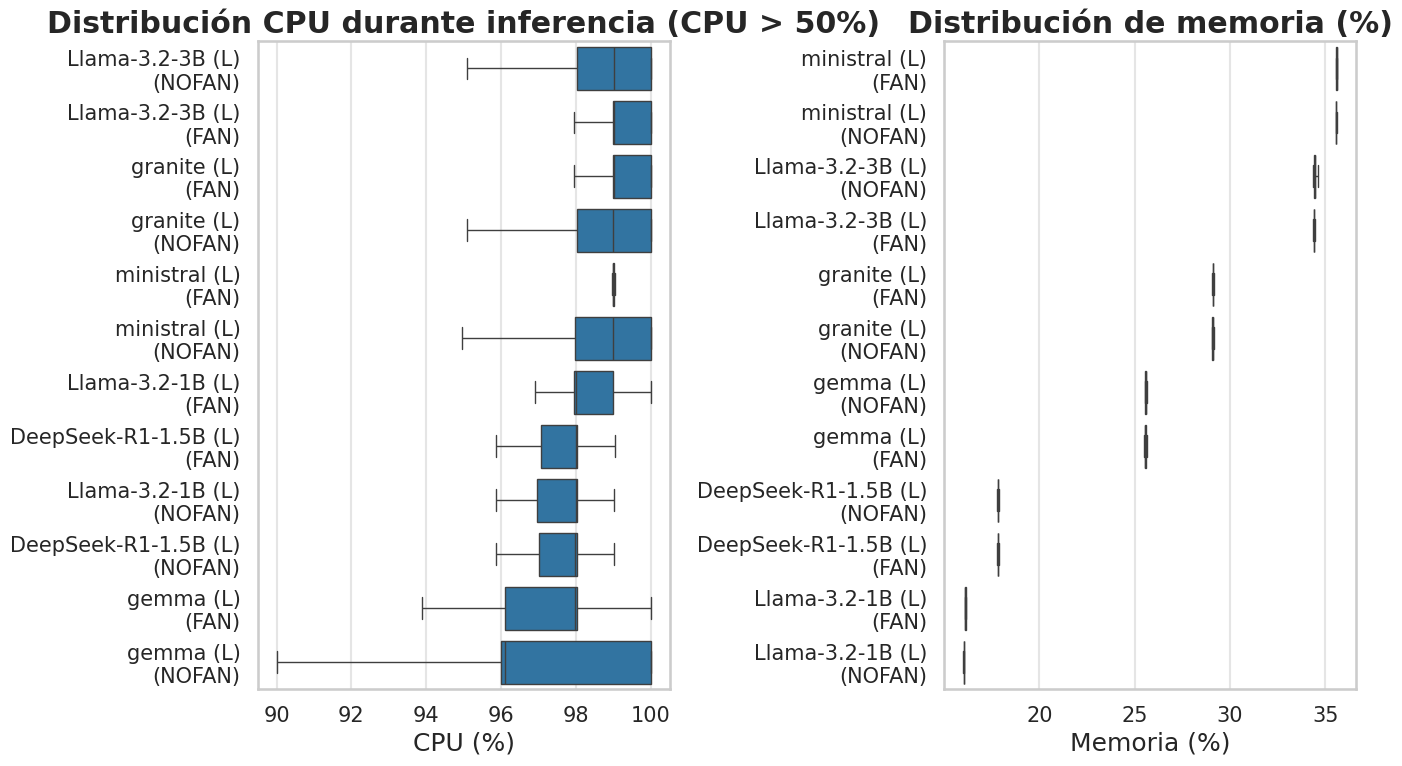

In [6]:
if not hw_df.empty:
    label_col = "config_label" if "config_label" in hw_df.columns else "model_label"
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    active = hw_df[hw_df['cpu_usage_pct'] > 50].copy()
    if not active.empty:
        order = (active.groupby(label_col)['cpu_usage_pct']
                 .median().sort_values(ascending=False).index.tolist())
        sns.boxplot(data=active, y=label_col, x='cpu_usage_pct',
                    order=order, showfliers=False, ax=axes[0])
        axes[0].set_title('Distribución CPU durante inferencia (CPU > 50%)')
        axes[0].set_xlabel('CPU (%)')
        axes[0].set_ylabel('')
    if 'mem_pct' in hw_df.columns:
        order_mem = (hw_df.groupby(label_col)['mem_pct']
                     .median().sort_values(ascending=False).index.tolist())
        sns.boxplot(data=hw_df, y=label_col, x='mem_pct',
                    order=order_mem, showfliers=False, ax=axes[1])
        axes[1].set_title('Distribución de memoria (%)')
        axes[1].set_xlabel('Memoria (%)')
        axes[1].set_ylabel('')
    fig.tight_layout()
    plt.show()
else:
    print('Sin datos de hardware para boxplots.')


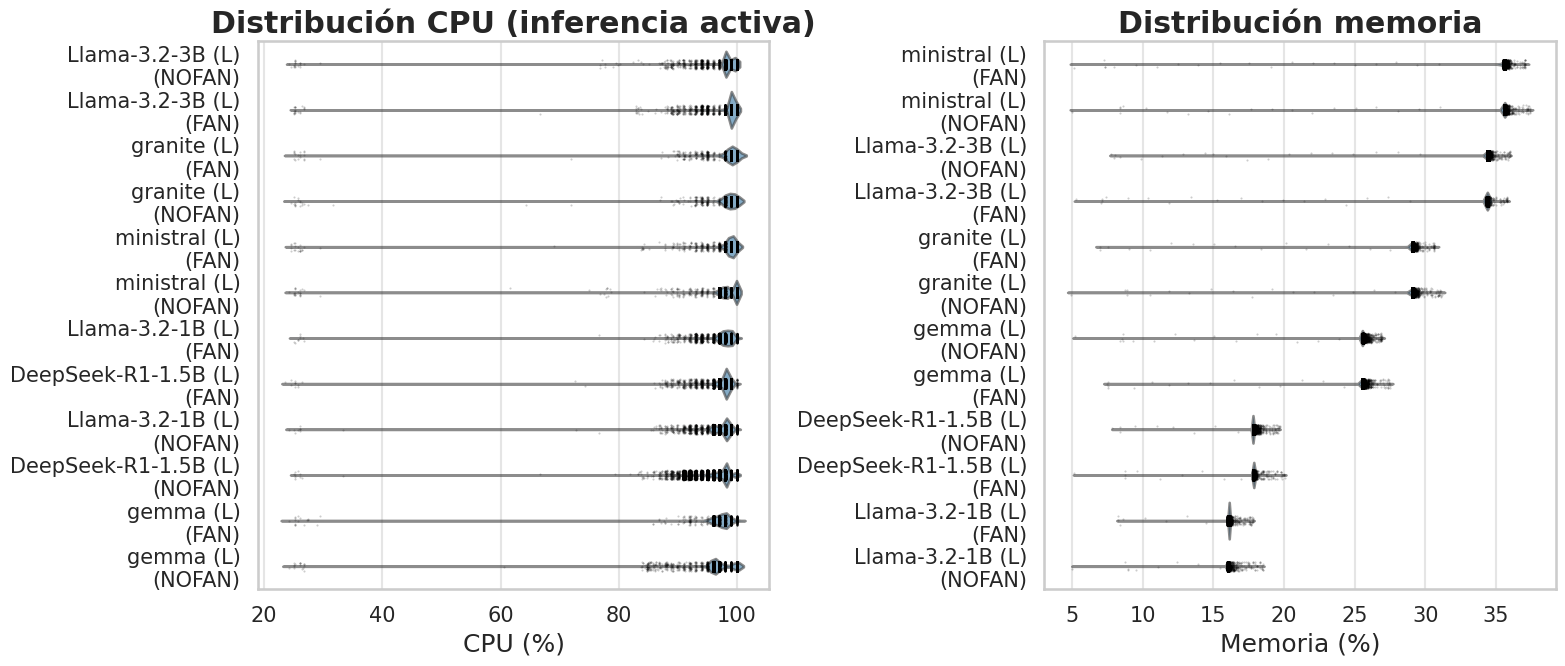

In [7]:
if not hw_df.empty:
    label_col = "config_label" if "config_label" in hw_df.columns else "model_label"
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, (col, xlabel, title) in zip(axes, [
        ('cpu_usage_pct', 'CPU (%)',     'Distribución CPU (inferencia activa)'),
        ('mem_pct',       'Memoria (%)', 'Distribución memoria'),
    ]):
        if col not in hw_df.columns:
            ax.text(0.5, 0.5, f'{col} no disponible', ha='center', va='center',
                    transform=ax.transAxes); continue
        data = hw_df[hw_df['cpu_usage_pct'] > 10].copy() if 'cpu' in col else hw_df.copy()
        if data.empty:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center',
                    transform=ax.transAxes); continue
        order = (data.groupby(label_col)[col]
                 .median().sort_values(ascending=False).index.tolist())
        sns.violinplot(data=data, y=label_col, x=col,
                       order=order, inner=None, alpha=0.6, ax=ax)
        sns.stripplot(data=data, y=label_col, x=col,
                      order=order, size=1.5, alpha=0.2, color='black', ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('')
    fig.tight_layout()
    plt.show()
else:
    print('Sin datos de hardware para violines.')


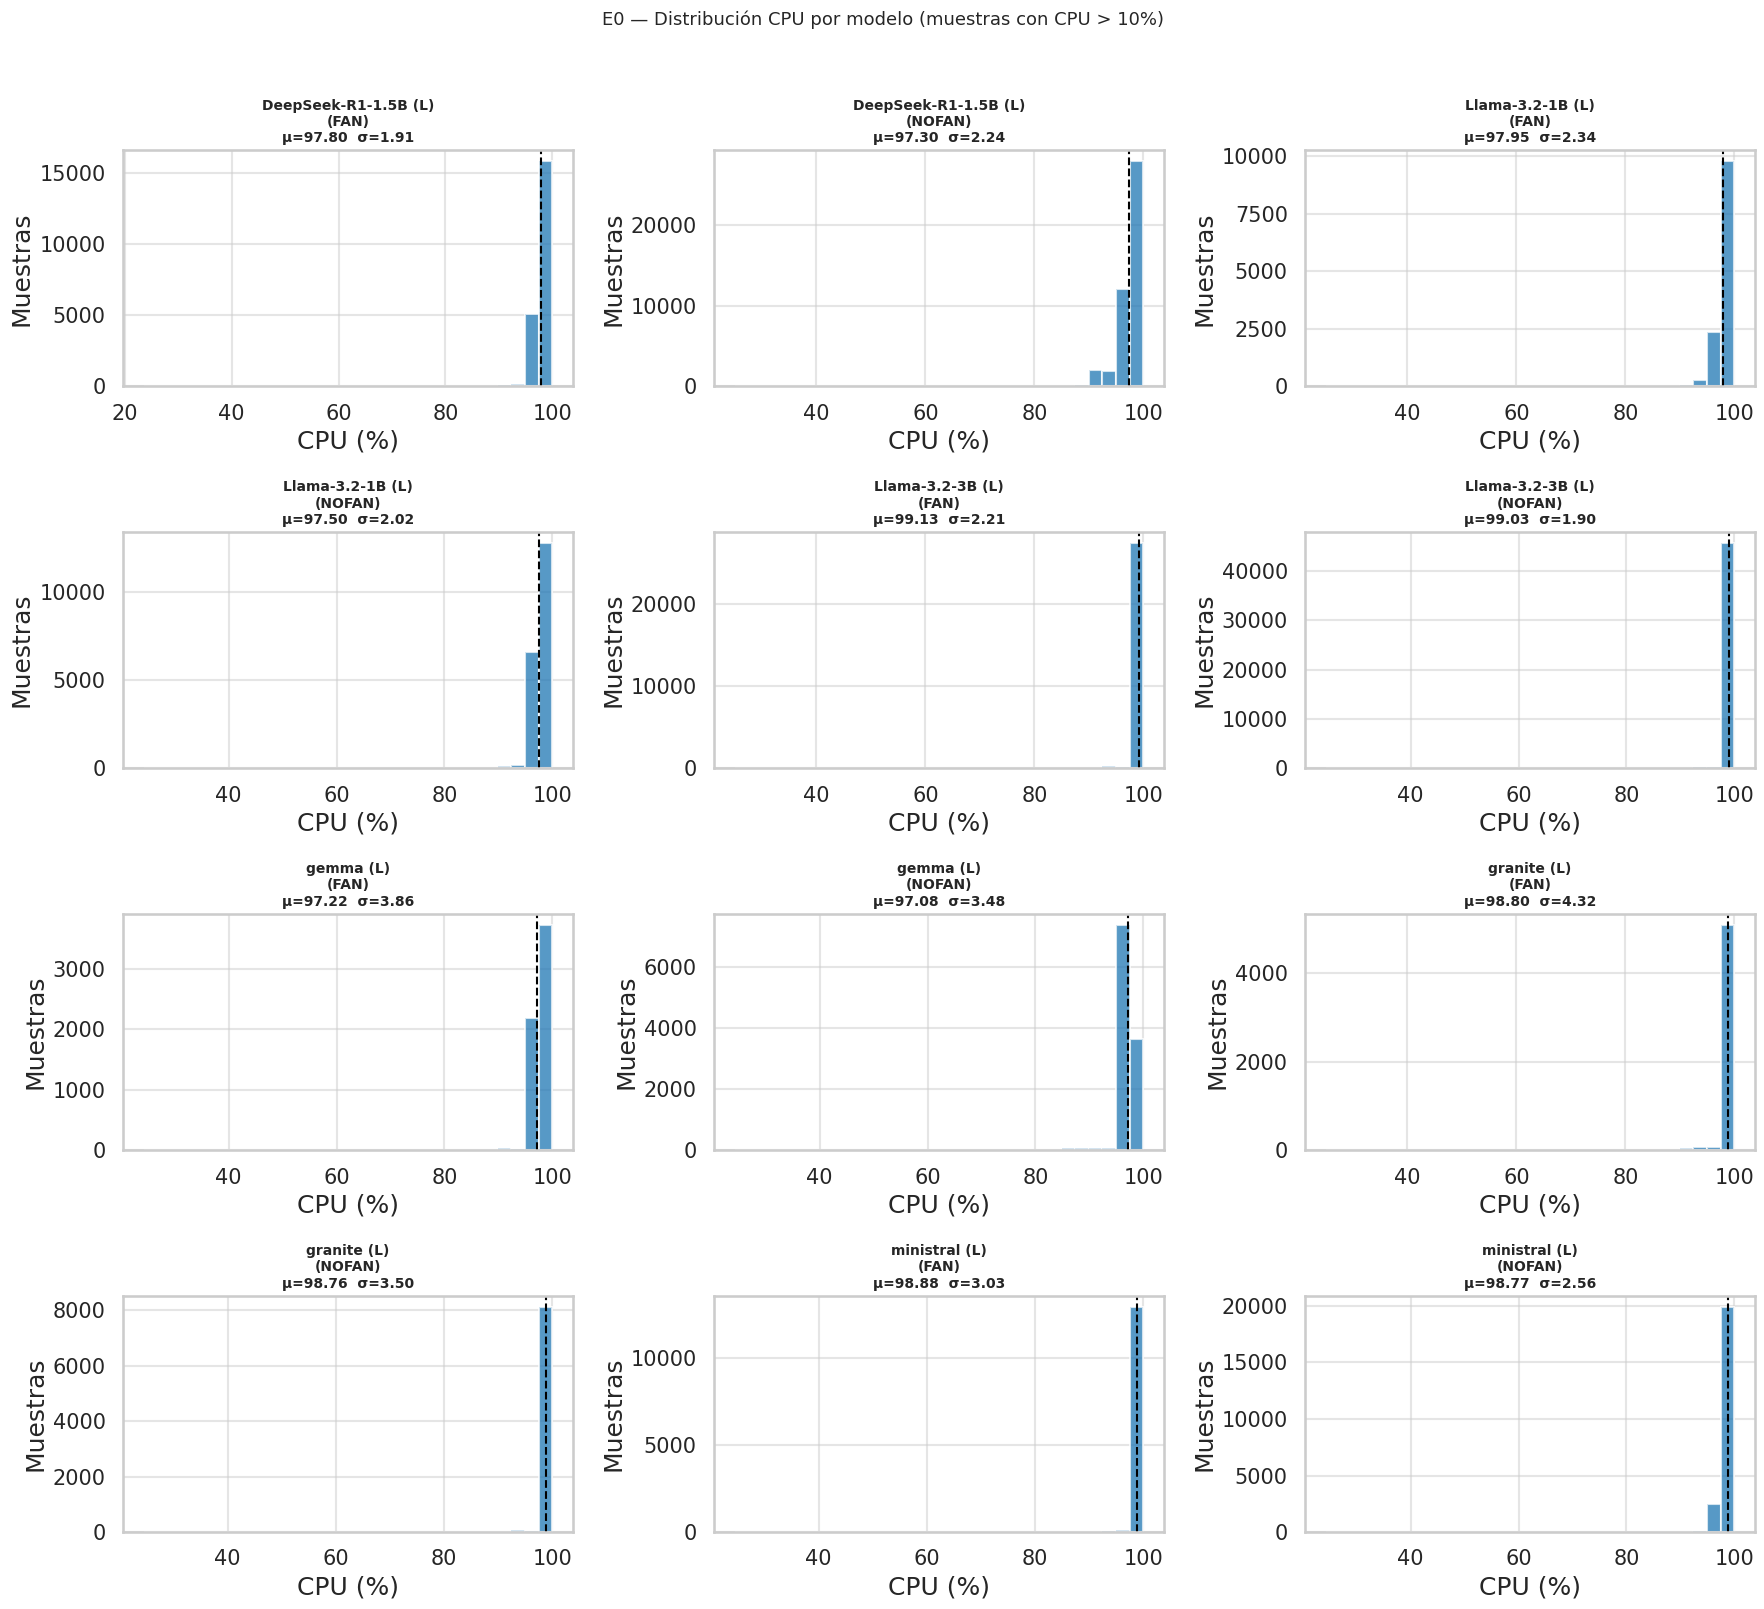

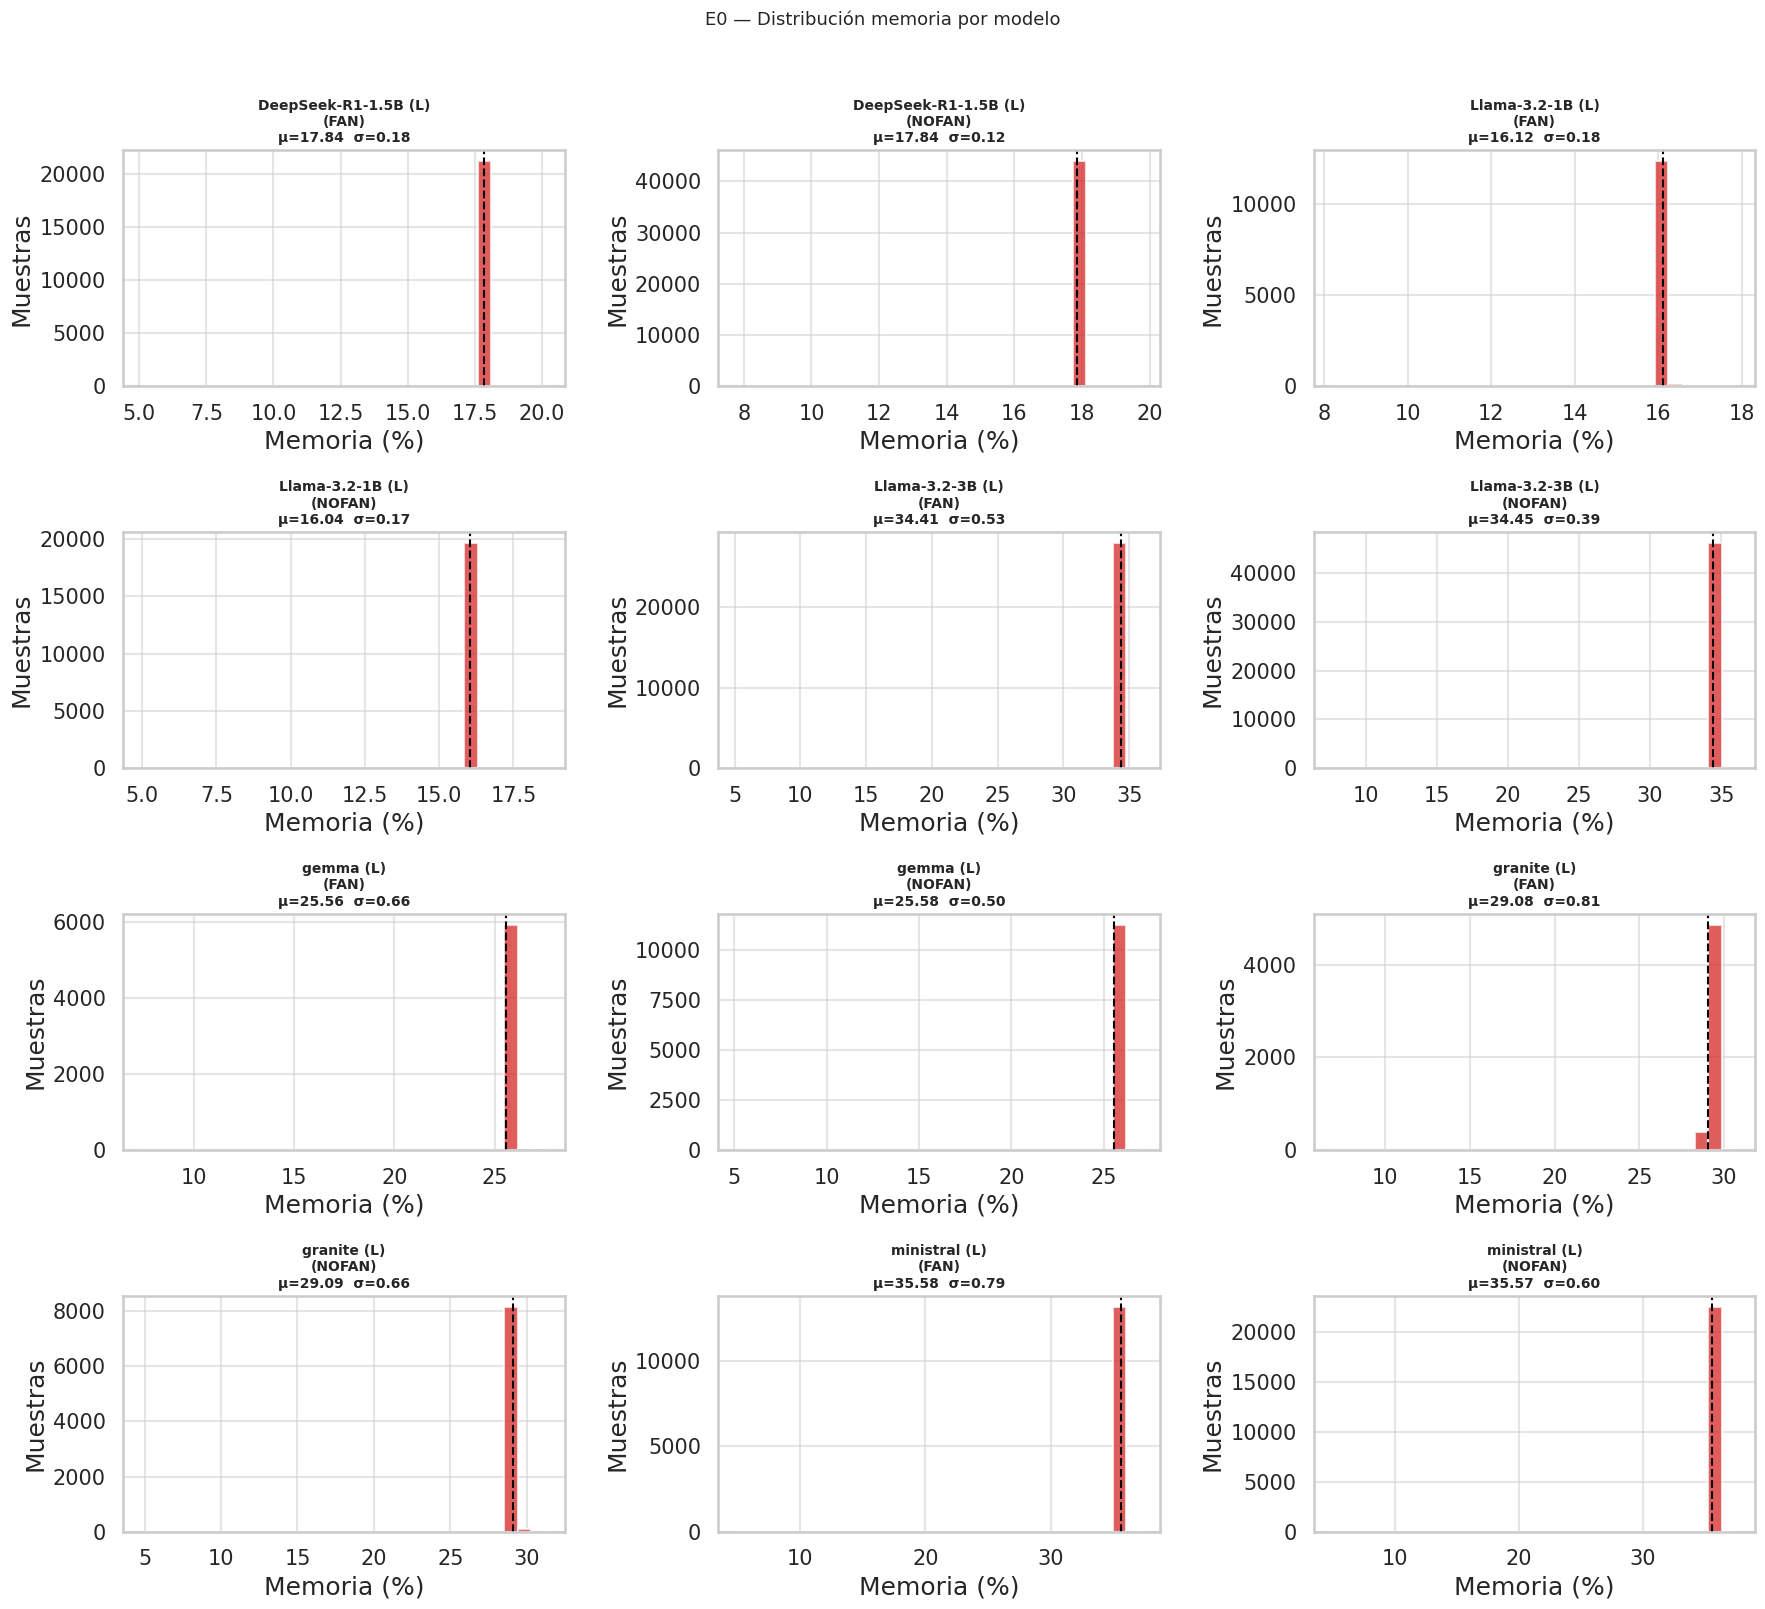

In [8]:
def _hist_by_model(hw_data, col, xlabel, color, suptitle,
                   xlim=None, vline=None):
    if col not in hw_data.columns:
        print(f'{col} no disponible'); return
    label_col = "config_label" if "config_label" in hw_data.columns else "model_label"
    models = sorted(hw_data[label_col].unique())
    ncols = 3
    nrows = -(-len(models) // ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4 * nrows),
                             sharey=False)
    axes_flat = axes.flatten() if nrows * ncols > 1 else [axes]
    for i, model in enumerate(models):
        ax = axes_flat[i]
        data = hw_data[hw_data[label_col] == model][col].dropna()
        if col == "cpu_usage_pct":
            data = data[data > 10]
        if data.empty:
            ax.set_visible(False); continue
        # Fijar rango explícito si xlim está definido para evitar expansión
        # automática de NumPy cuando todos los valores son iguales
        hist_range = xlim if xlim else (data.min(), data.max())
        if hist_range[0] == hist_range[1]:
            hist_range = (hist_range[0] - 0.5, hist_range[1] + 0.5)
        ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white',
                range=hist_range)
        ax.axvline(data.mean(), color='black', ls='--', lw=1.5)
        if vline is not None:
            ax.axvline(vline, color='gray', ls=':', lw=1.2,
                       label=f'{vline} GHz nom.')
            ax.legend(fontsize=7)
        if xlim:
            ax.set_xlim(*xlim)
        ax.set_title(f"{model}\n\u03bc={data.mean():.2f}  \u03c3={data.std():.2f}",
                     fontsize=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Muestras")
    for j in range(len(models), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_df.empty:
    _hist_by_model(hw_df, "cpu_usage_pct", "CPU (%)", "tab:blue",
                   "E0 \u2014 Distribuci\u00f3n CPU por modelo (muestras con CPU > 10%)")
    _hist_by_model(hw_df, "mem_pct", "Memoria (%)", "tab:red",
                   "E0 \u2014 Distribuci\u00f3n memoria por modelo")
else:
    print('Sin datos de hardware para histogramas.')


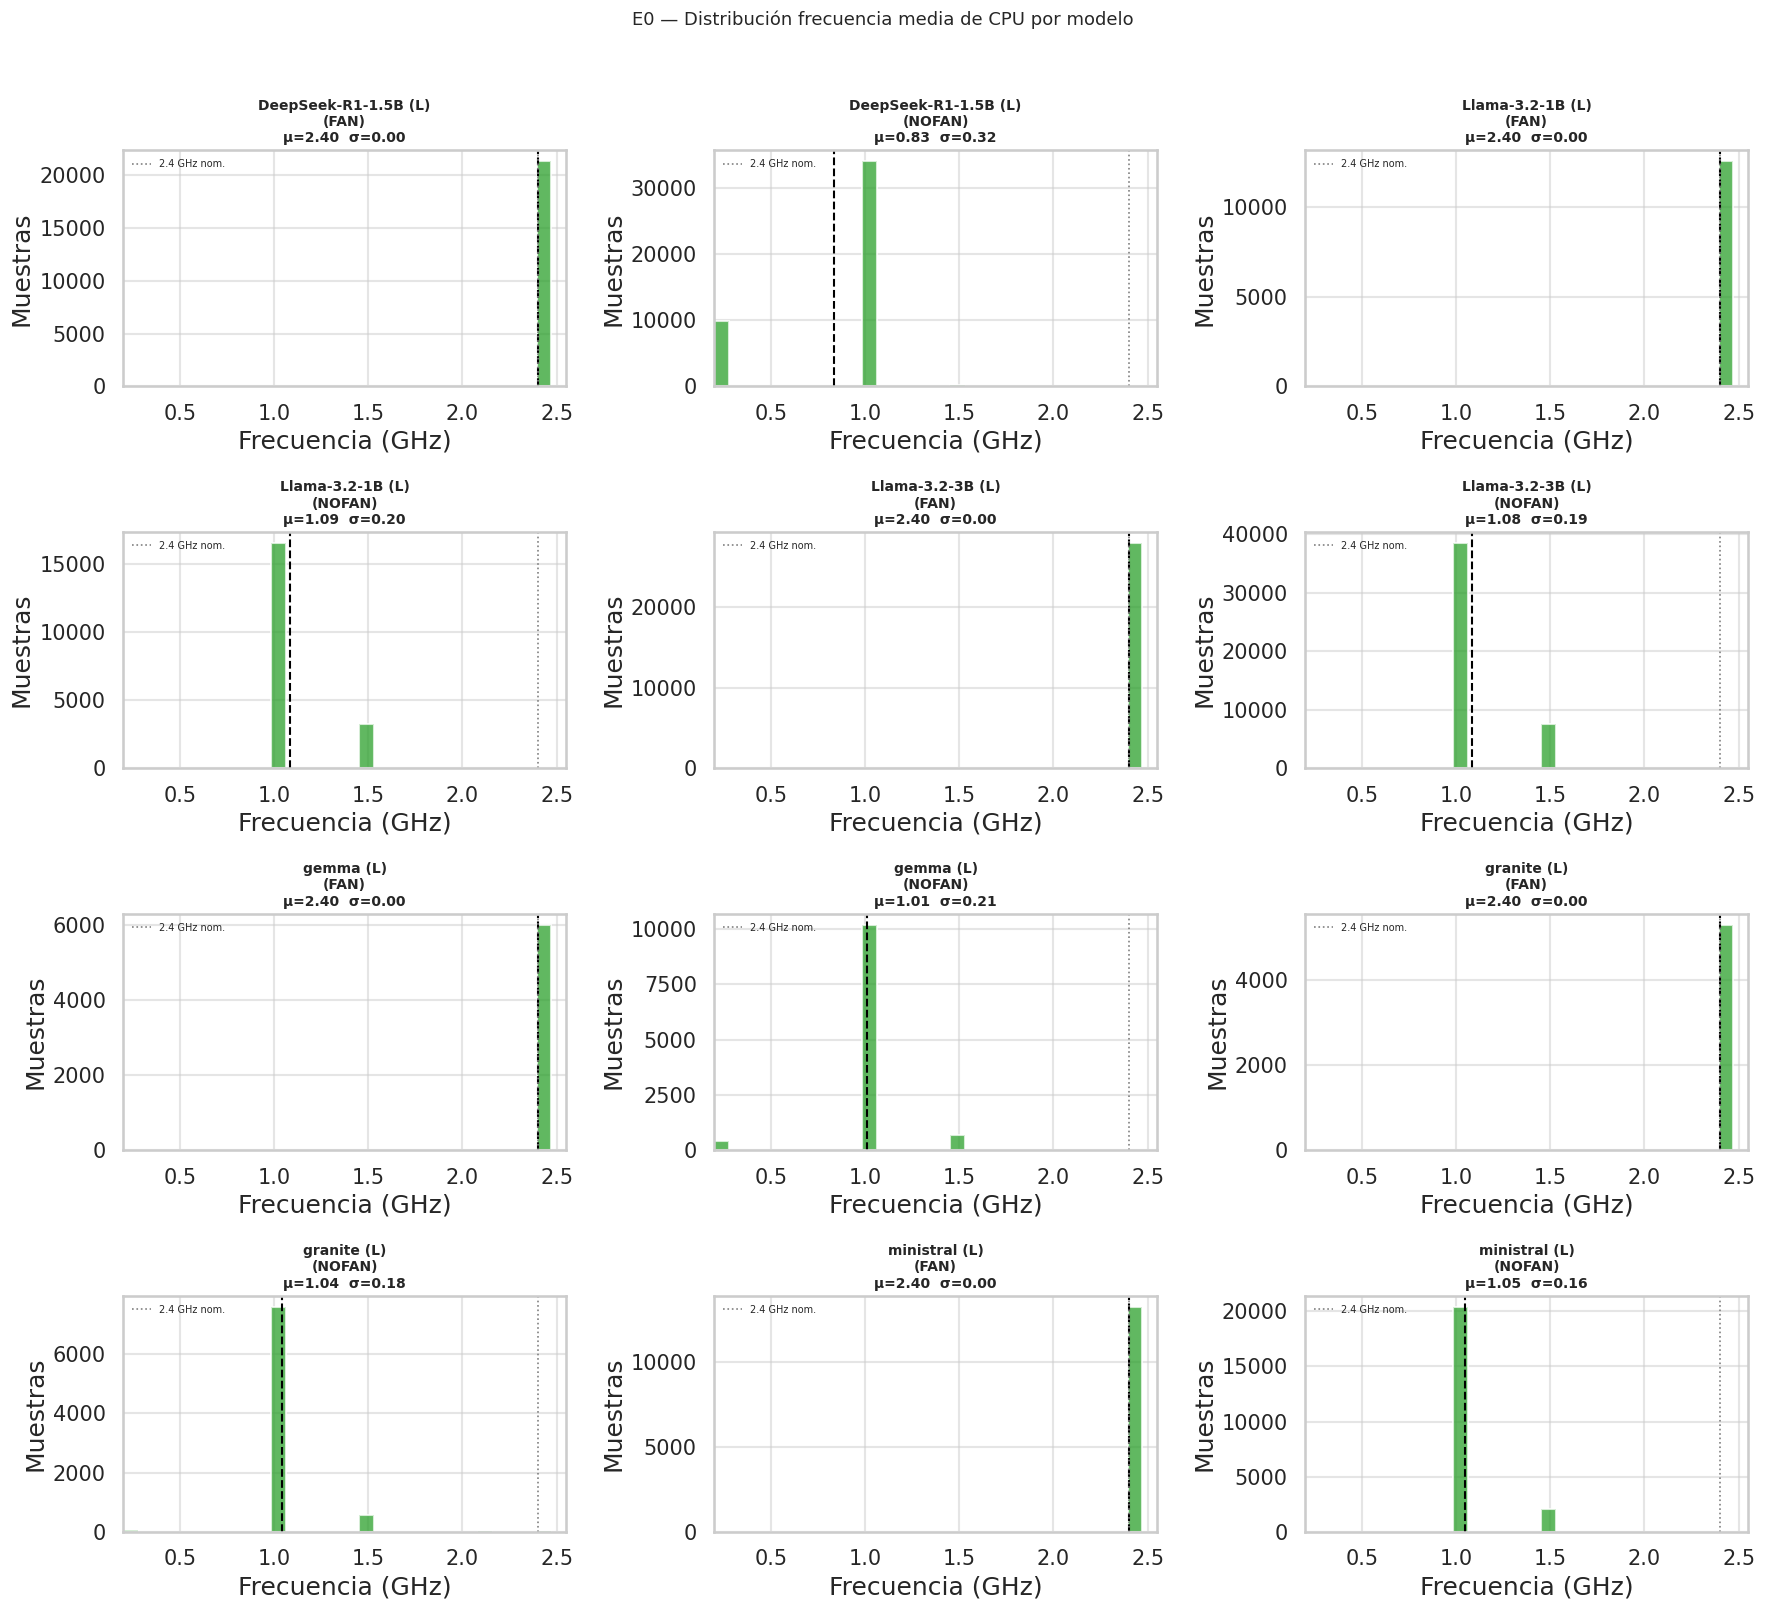

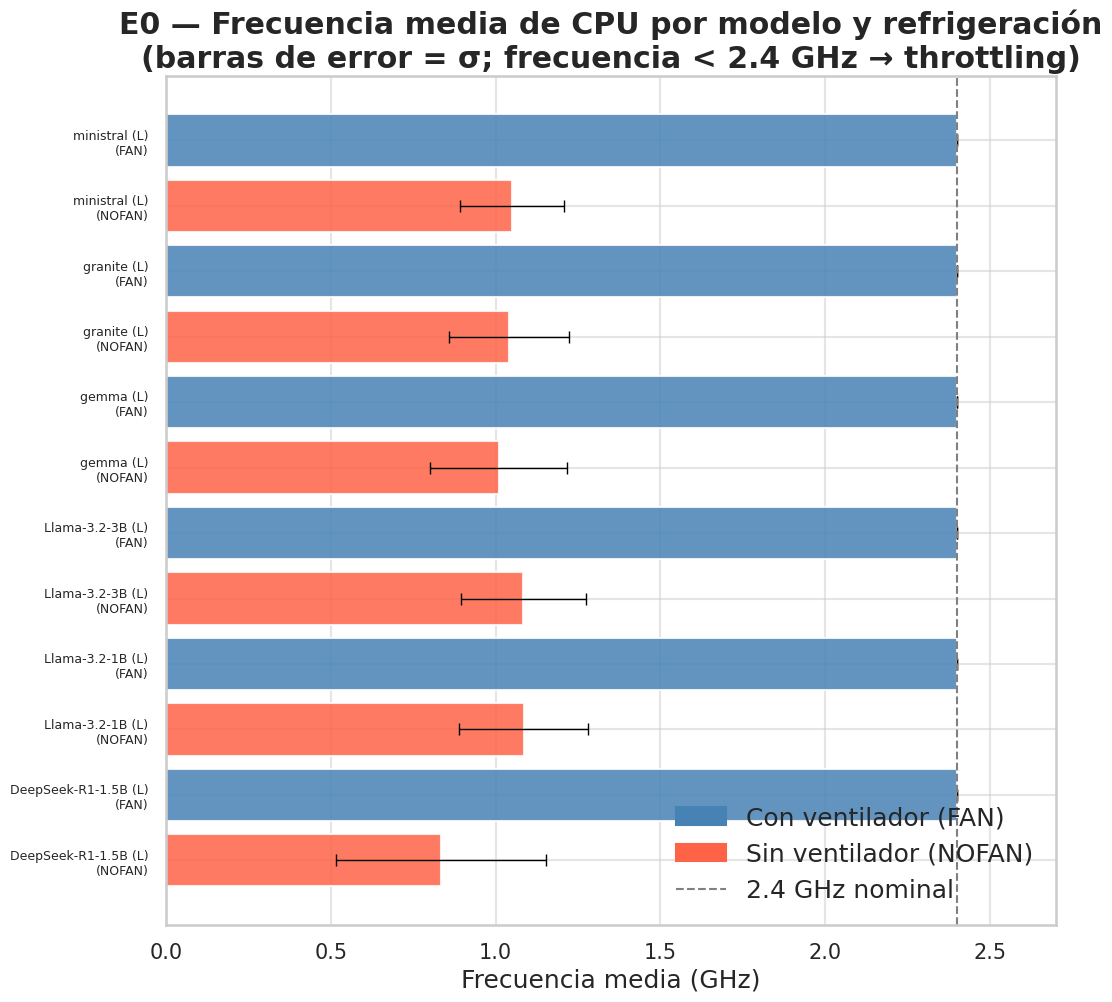


Frecuencia media (GHz) durante inferencia activa:


,config,mean,std
0,DeepSeek-R1-1.5B (L)\n(NOFAN),0.835,0.318
1,DeepSeek-R1-1.5B (L)\n(FAN),2.400,0.000
2,Llama-3.2-1B (L)\n(NOFAN),1.085,0.196
3,Llama-3.2-1B (L)\n(FAN),2.400,0.000
4,Llama-3.2-3B (L)\n(NOFAN),1.084,0.190
5,Llama-3.2-3B (L)\n(FAN),2.400,0.000
6,gemma (L)\n(NOFAN),1.009,0.207
7,gemma (L)\n(FAN),2.400,0.000
8,granite (L)\n(NOFAN),1.040,0.183
9,granite (L)\n(FAN),2.400,0.000


In [9]:
if not hw_df.empty and 'freq_mean_ghz' in hw_df.columns:
    _hist_by_model(hw_df, "freq_mean_ghz", "Frecuencia (GHz)", "tab:green",
                   "E0 — Distribución frecuencia media de CPU por modelo",
                   xlim=(0.2, 2.55), vline=2.4)

    freq_summary = (hw_df[hw_df["cpu_usage_pct"] > 10]
                    .groupby(["model_label","fan"])["freq_mean_ghz"]
                    .agg(mean="mean", std="std")
                    .reset_index())
    if not freq_summary.empty:
        freq_summary["config"] = (
            freq_summary["model_label"] + "\n(" +
            freq_summary["fan"].map({True: "FAN", False: "NOFAN"}) + ")"
        )
        freq_summary = freq_summary.sort_values(["model_label","fan"])

        n_bars  = len(freq_summary)
        fig_h   = max(6, n_bars * 0.9)
        fig, ax = plt.subplots(figsize=(11, fig_h))
        bar_colors = freq_summary["fan"].map({True: "steelblue", False: "tomato"})
        ax.barh(freq_summary["config"], freq_summary["mean"],
                xerr=freq_summary["std"], color=bar_colors, alpha=0.85,
                capsize=4, error_kw={"elinewidth": 1, "ecolor": "black"})
        ax.axvline(2.4, ls='--', color='gray', lw=1.5)
        ax.set_xlim(0, 2.7)
        ax.set_xlabel("Frecuencia media (GHz)")
        ax.set_title(
            "E0 — Frecuencia media de CPU por modelo y refrigeración\n"
            "(barras de error = σ; frecuencia < 2.4 GHz → throttling)"
        )
        from matplotlib.patches import Patch
        import matplotlib.lines as mlines
        leg_elems = [
            Patch(color="steelblue", label="Con ventilador (FAN)"),
            Patch(color="tomato",    label="Sin ventilador (NOFAN)"),
            mlines.Line2D([],[],color='gray',ls='--',lw=1.5,label="2.4 GHz nominal"),
        ]
        ax.legend(handles=leg_elems, loc="lower right")
        ax.tick_params(axis='y', labelsize=9)
        plt.subplots_adjust(left=0.28)
        plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])
        plt.show()

        print("\nFrecuencia media (GHz) durante inferencia activa:")
        display(freq_summary[["config","mean","std"]].round(3))
else:
    print('freq_mean_ghz no disponible en hw_df.')


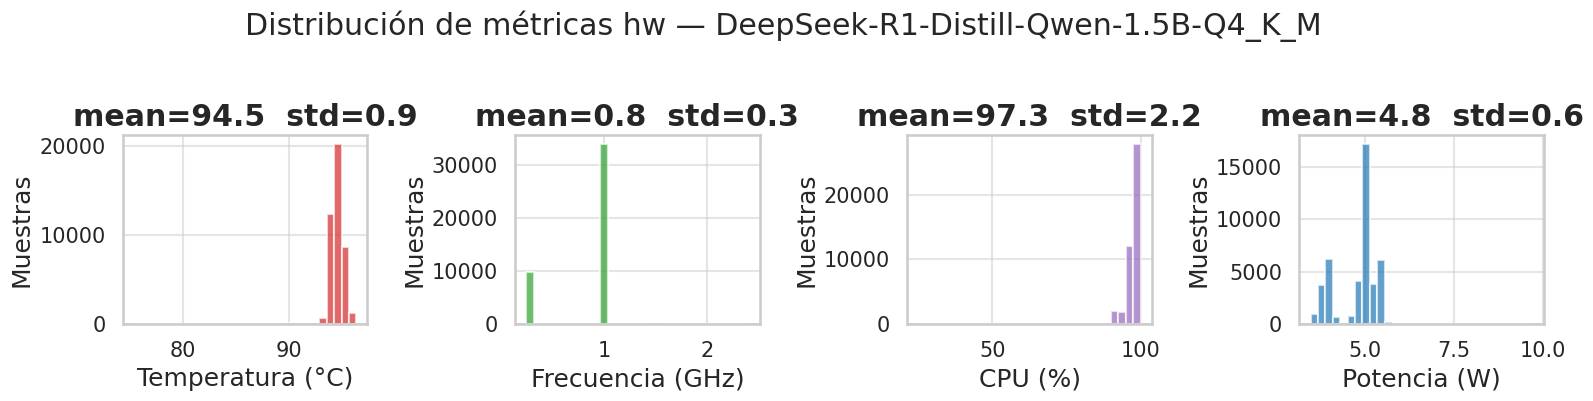

In [10]:
if not hw_df.empty and not summary.empty and 'throttled_ratio' in summary.columns:
    _rep_id = summary.sort_values('throttled_ratio', ascending=False)['run_id'].iloc[0]
    hw_rep  = hw_df[hw_df['run_id'] == _rep_id]
    run_rep = next((r for r in coll.runs if r.run_id == _rep_id), None)
    if run_rep is not None and not hw_rep.empty:
        try:
            fig = hw_distributions_panel(hw_rep, run_rep)
            plt.show()
        except Exception as e:
            print(f'hw_distributions_panel: {e}')
    else:
        print('Run representativo no encontrado para hw_distributions_panel.')
else:
    print('Sin datos para panel de histogramas hw.')


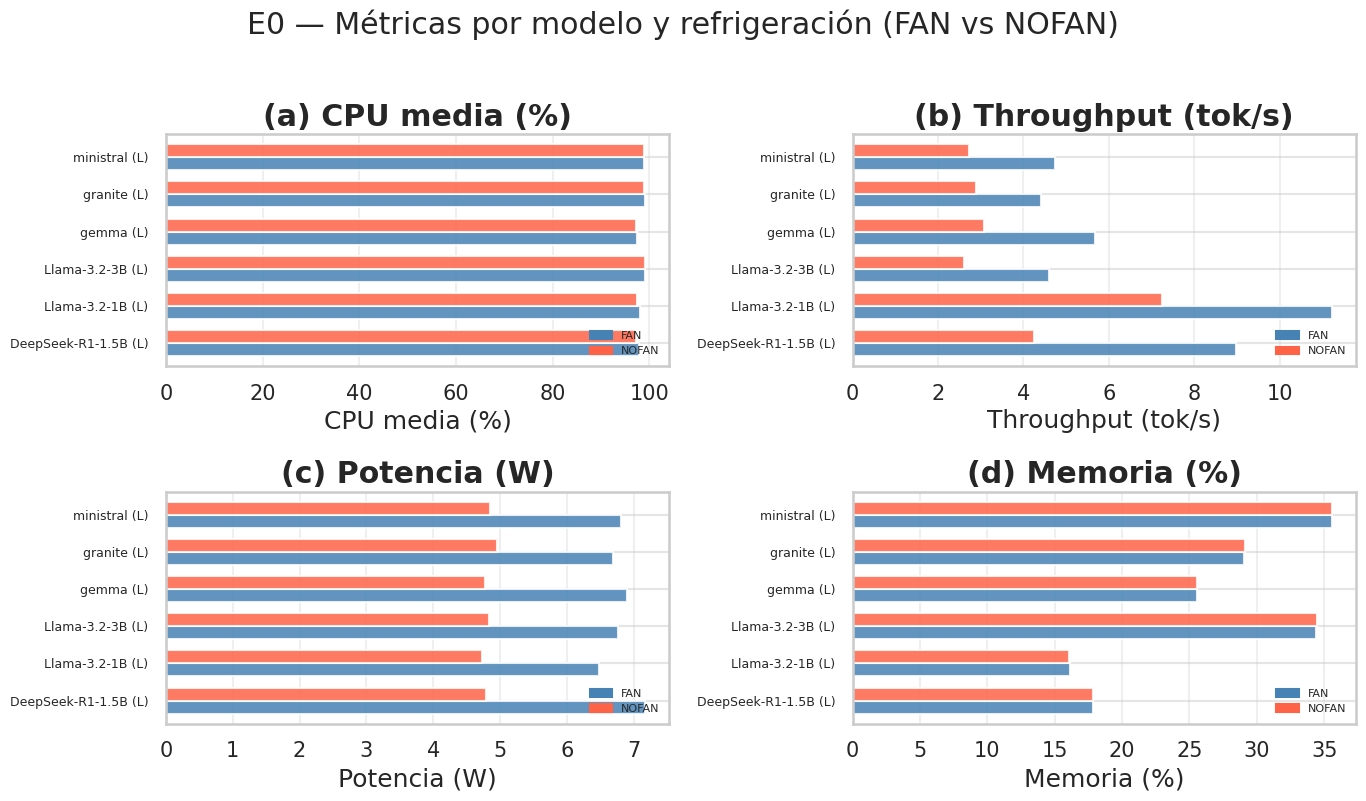

In [11]:
if not hw_df.empty and not pm_df.empty and not summary.empty:
    pm_valid_tmp = pm_df[~pm_df['is_empty_generation']].copy()

    hw_rows = []
    for _, row in summary.iterrows():
        rid   = row.get('run_id')
        fan_v = row.get('fan', False)
        hw_r  = hw_df[hw_df['run_id'] == rid] if rid else pd.DataFrame()
        pm_r  = pm_valid_tmp[pm_valid_tmp['run_id'] == rid] if rid else pd.DataFrame()
        if hw_r.empty: continue
        active_r = hw_r[hw_r['cpu_usage_pct'] > 50]
        hw_rows.append({
            'model_label': row['model_label'],
            'fan':    'FAN' if fan_v else 'NOFAN',
            'cpu_pct':  active_r['cpu_usage_pct'].mean() if not active_r.empty else float('nan'),
            'tokens_s': pm_r['tokens_per_second'].mean() if not pm_r.empty else float('nan'),
            'power_w':  hw_r['internal_power_w'].mean(),
            'mem_pct':  hw_r['mem_pct'].mean() if 'mem_pct' in hw_r.columns else float('nan'),
        })

    if hw_rows:
        from matplotlib.patches import Patch
        hw_sum  = pd.DataFrame(hw_rows)
        models  = sorted(hw_sum['model_label'].unique())
        y       = np.arange(len(models))
        width   = 0.35
        METRICS = [
            ('cpu_pct',  'CPU media (%)',      '(a)'),
            ('tokens_s', 'Throughput (tok/s)', '(b)'),
            ('power_w',  'Potencia (W)',        '(c)'),
            ('mem_pct',  'Memoria (%)',         '(d)'),
        ]
        fig, axes = plt.subplots(2, 2, figsize=(14, max(8, len(models) * 1.1)))
        for ax, (col, xlabel, label) in zip(axes.flatten(), METRICS):
            for offset, fan_str, color in [
                (-width/2, 'FAN',   'steelblue'),
                ( width/2, 'NOFAN', 'tomato'),
            ]:
                vals = [
                    hw_sum[(hw_sum['model_label'] == m) & (hw_sum['fan'] == fan_str)][col].mean()
                    if not hw_sum[(hw_sum['model_label'] == m) & (hw_sum['fan'] == fan_str)].empty
                    else float('nan')
                    for m in models
                ]
                ax.barh(y + offset, vals, width, label=fan_str,
                        color=color, alpha=0.85)
            ax.set_yticks(y)
            ax.set_yticklabels(models, fontsize=9)
            ax.set_xlabel(xlabel)
            ax.set_title(f'{label} {xlabel}', fontweight='bold')
            ax.grid(True, axis='x', alpha=0.3)
            ax.legend(handles=[Patch(color='steelblue', label='FAN'),
                                Patch(color='tomato',   label='NOFAN')],
                      fontsize=8, loc='lower right')
        fig.suptitle('E0 \u2014 M\u00e9tricas por modelo y refrigeraci\u00f3n (FAN vs NOFAN)',
                     y=1.01)
        fig.tight_layout(); plt.show()
    else:
        print('Sin datos para grouped bar chart.')
else:
    print('Sin datos suficientes para grouped bar chart.')


## 4. Métricas de inferencia

Distribución de las métricas de rendimiento por prompt para cada
configuración del experimento.

In [12]:
def _plot_metric(df, metric, ylabel='', title='', unit_label=''):
    """Barplot horizontal agrupado por config_label cuando está disponible."""
    label_col = 'config_label' if 'config_label' in df.columns else 'model_label'
    data = df.dropna(subset=[metric]).copy()
    if data.empty:
        print(f'Sin datos para {metric}'); return
    means = data.groupby(label_col)[metric].mean().sort_values()
    full_title = f'{title}' + (f' ({unit_label})' if unit_label else '')
    fig, ax = plt.subplots(figsize=(10, max(4, len(means) * 0.55)))
    ax.barh(range(len(means)), means.values, alpha=0.85, color='steelblue')
    ax.set_yticks(range(len(means)))
    ax.set_yticklabels(means.index, fontsize=9)
    ax.set_xlabel(unit_label or ylabel or metric)
    ax.set_title(full_title)
    ax.grid(True, axis='x', alpha=0.3)
    fig.tight_layout()
    plt.show()


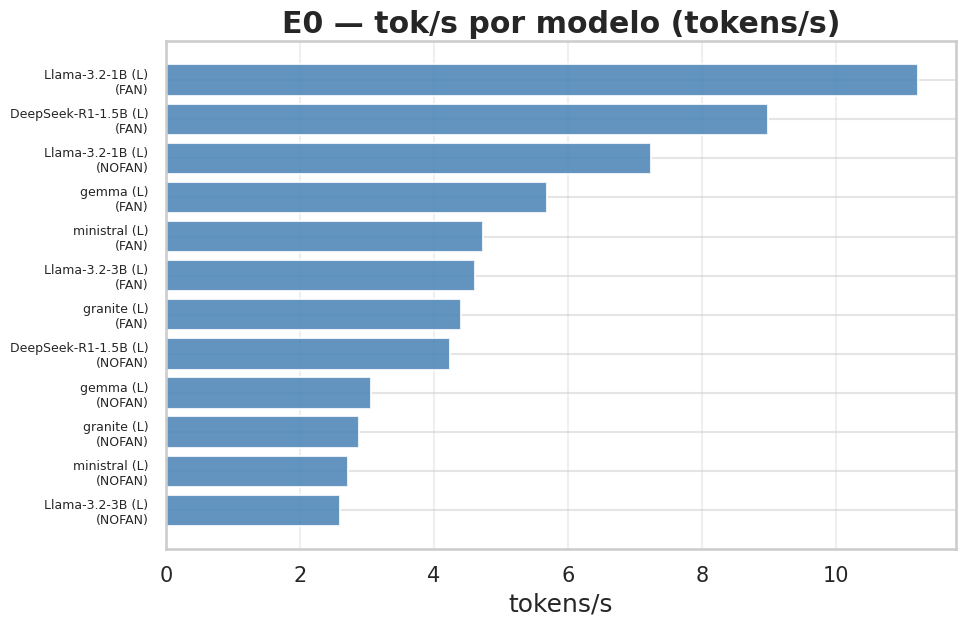

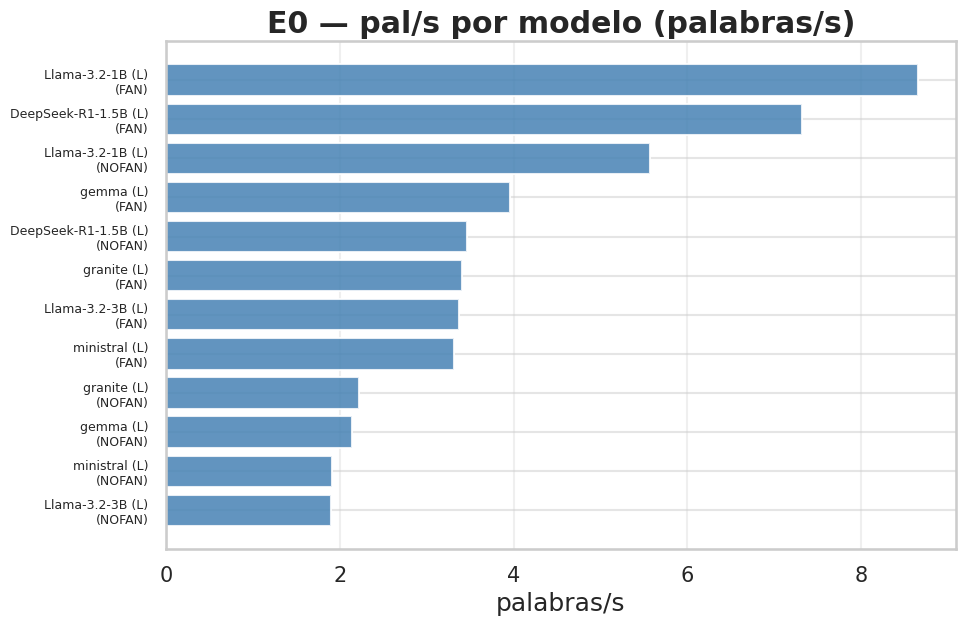

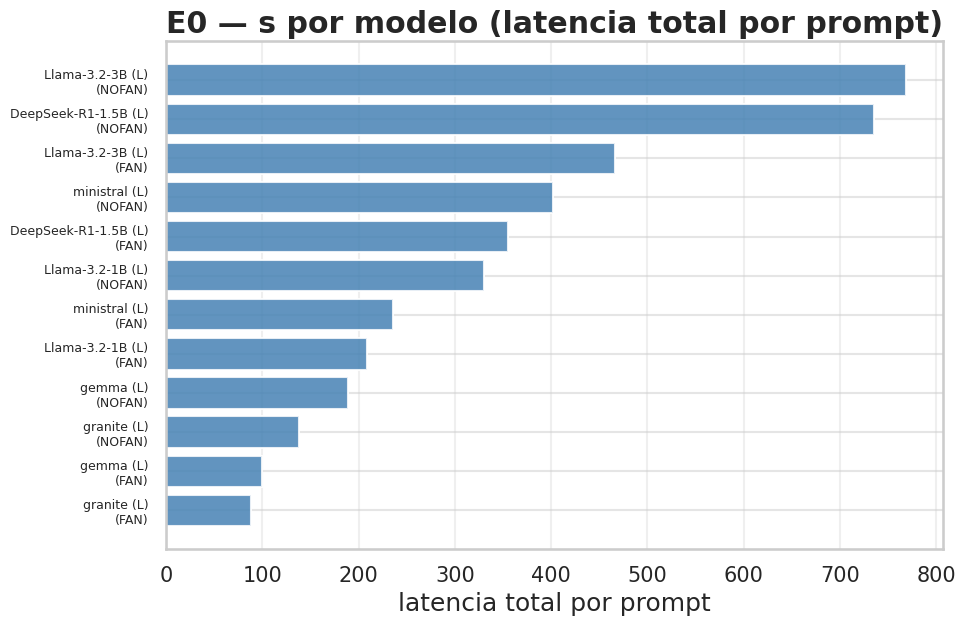

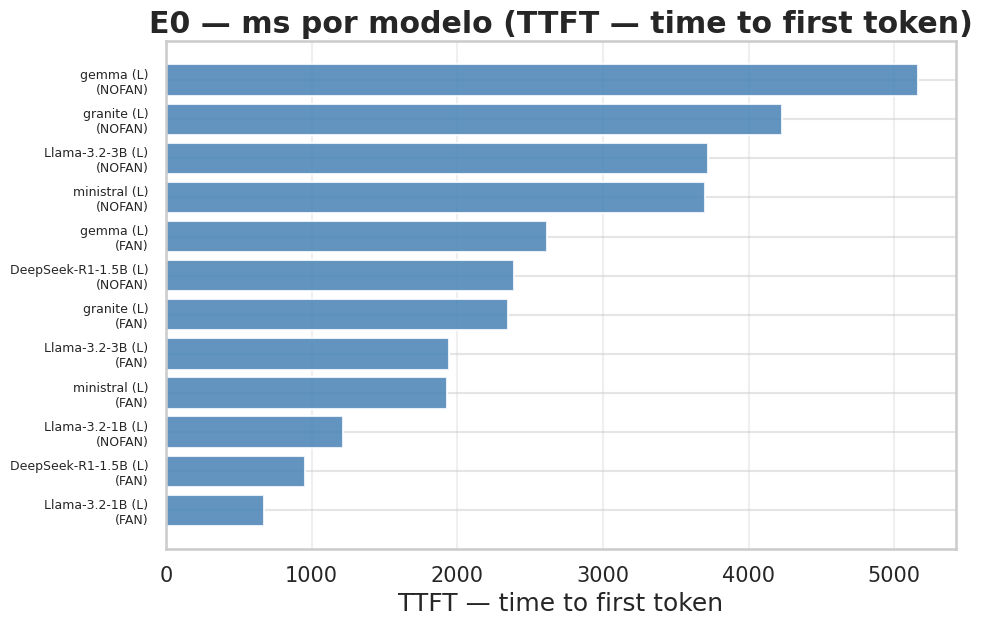

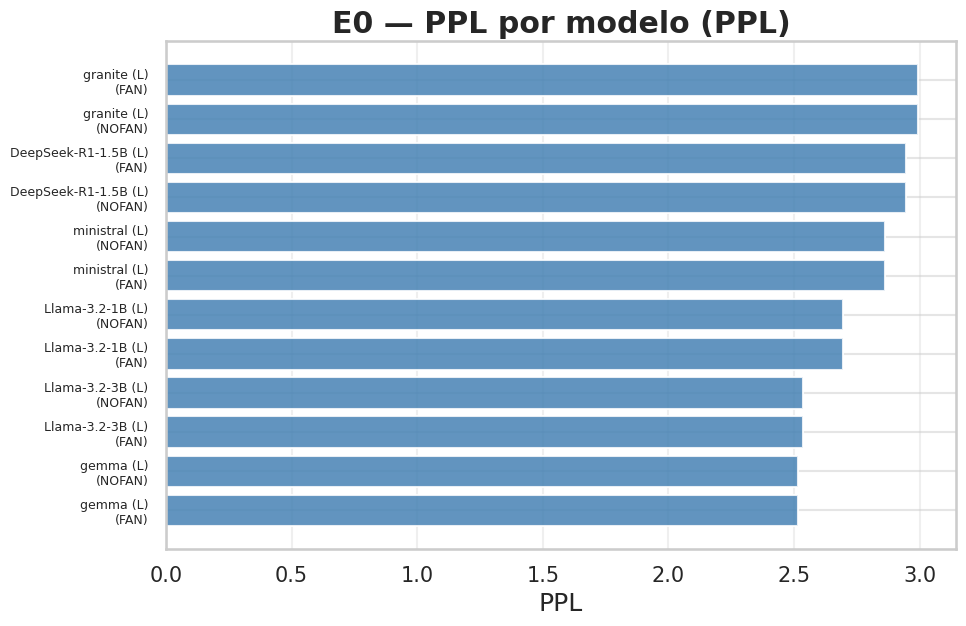

In [13]:
pm_valid = pm_df[~pm_df['is_empty_generation']].copy() if not pm_df.empty else pd.DataFrame()

if not pm_valid.empty:
    if 'latency_ms' in pm_valid.columns:
        pm_valid['latency_s'] = pm_valid['latency_ms'] / 1000

    for metric, ylabel, unit in [
        ('tokens_per_second',      'tok/s', 'tokens/s'),
        ('words_per_second',       'pal/s', 'palabras/s'),
        ('latency_s',              's',     'latencia total por prompt'),
        ('time_to_first_token_ms', 'ms',    'TTFT — time to first token'),
        ('perplexity',             'PPL',   'PPL'),
    ]:
        if metric in pm_valid.columns:
            _plot_metric(pm_valid, metric, ylabel=ylabel,
                         title=f'E0 \u2014 {ylabel} por modelo', unit_label=unit)
        else:
            print(f'M\u00e9trica no disponible: {metric}')
else:
    print('Sin prompts v\u00e1lidos para m\u00e9tricas de inferencia.')


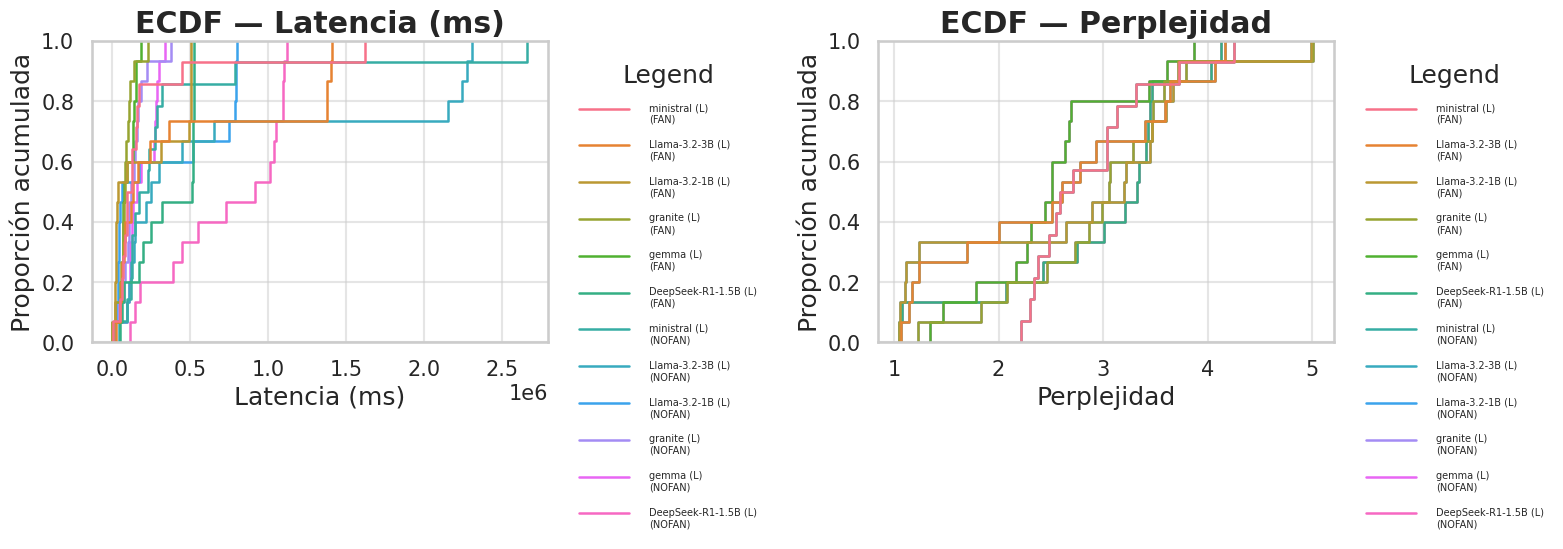

In [14]:
if not pm_valid.empty:
    hue_col   = 'config_label' if 'config_label' in pm_valid.columns else 'model_label'
    ecdf_cols = [(c, lbl) for c, lbl in [
        ('latency_ms', 'Latencia (ms)'),
        ('perplexity', 'Perplejidad'),
    ] if c in pm_valid.columns]
    if ecdf_cols:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        for ax, (col, xlabel) in zip(axes, ecdf_cols):
            sns.ecdfplot(data=pm_valid.dropna(subset=[col]),
                         x=col, hue=hue_col, ax=ax)
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Proporci\u00f3n acumulada')
            ax.set_title(f'ECDF \u2014 {xlabel}')
            lgd = ax.get_legend()
            if lgd:
                lgd.set_title("Legend")
                lgd.set_bbox_to_anchor((1.02, 1))
                lgd.set_loc('upper left')
                for txt in lgd.get_texts():
                    txt.set_fontsize(7)
        # Ocultar segundo ax si solo hay un ECDF
        if len(ecdf_cols) == 1:
            axes[1].set_visible(False)
        fig.tight_layout()
        plt.show()
else:
    print('Sin datos para ECDFs.')


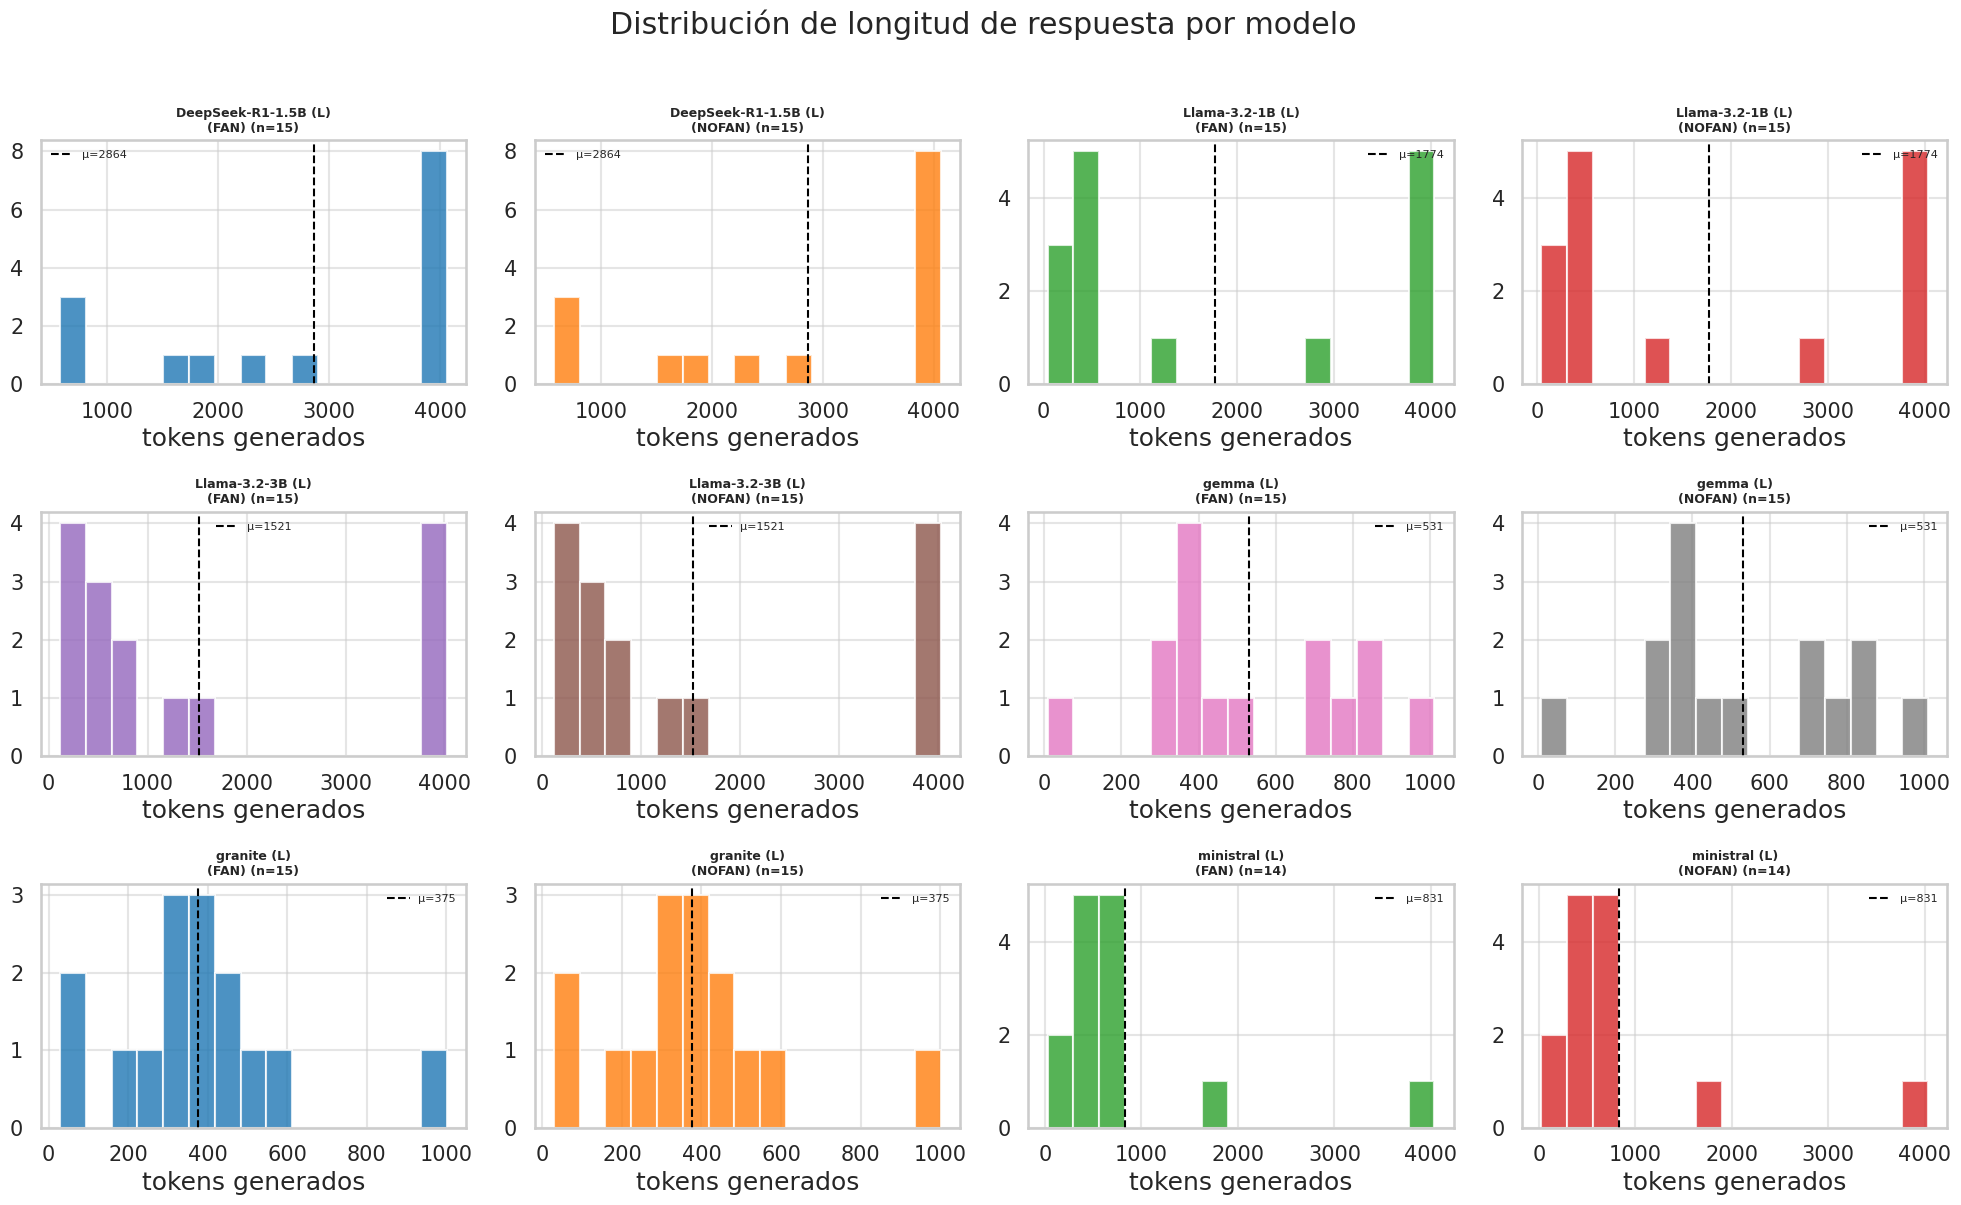


Resumen (tokens generados):


,count,mean,std,min,max
config_label,,,,,
DeepSeek-R1-1.5B (L)\n(FAN),15,2863.7,1402.2,574,4059
DeepSeek-R1-1.5B (L)\n(NOFAN),15,2863.7,1402.2,574,4059
Llama-3.2-1B (L)\n(FAN),15,1773.5,1765.7,42,4035
Llama-3.2-1B (L)\n(NOFAN),15,1773.5,1765.7,42,4035
Llama-3.2-3B (L)\n(FAN),15,1520.9,1582.0,115,4023
Llama-3.2-3B (L)\n(NOFAN),15,1520.9,1582.0,115,4023
gemma (L)\n(FAN),15,530.9,273.7,9,1011
gemma (L)\n(NOFAN),15,530.9,273.7,9,1011
granite (L)\n(FAN),15,375.2,228.7,29,1001


In [15]:
if not pm_valid.empty and 'eval_count' in pm_valid.columns:
    label_col = 'config_label' if 'config_label' in pm_valid.columns else 'model_label'
    models = sorted(pm_valid[label_col].unique())
    ncols = min(4, len(models))
    nrows = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    for i, model in enumerate(models):
        if i >= len(axes_flat):
            break
        ax = axes_flat[i]
        data = pm_valid[pm_valid[label_col] == model]['eval_count'].dropna()
        ax.hist(data, bins=15, color=f'C{i}', alpha=0.8, edgecolor='white')
        ax.axvline(data.mean(), ls='--', color='black', lw=1.5,
                   label=f'\u03bc={data.mean():.0f}')
        ax.set_title(f'{model} (n={len(data)})', fontsize=9)
        ax.set_xlabel('tokens generados')
        ax.legend(fontsize=8)
    for j in range(len(models), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle('Distribuci\u00f3n de longitud de respuesta por modelo', y=1.01)
    fig.tight_layout()
    plt.show()

    print('\nResumen (tokens generados):')
    display(pm_valid.groupby(label_col)['eval_count']
            .agg(['count', 'mean', 'std', 'min', 'max']).round(1))
else:
    print('Sin datos para distribuci\u00f3n de longitud de respuesta.')


## 5. Eficiencia energética y trabajo CPU efectivo

**W_CPU (core·s)**: trabajo computacional efectivo = ∫(f(t)/f_nom)·(CPU(t)/100)·N_cores·dt.  
Análogo a "persona-hora". Con throttling al 50% de frecuencia, W_CPU es
la mitad que a frecuencia nominal en el mismo tiempo real.

**η_CPU**: eficiencia CPU = W_CPU / (N_cores·T). Rango [0,1].

**W_token (core·s/token)**: coste computacional por token generado.

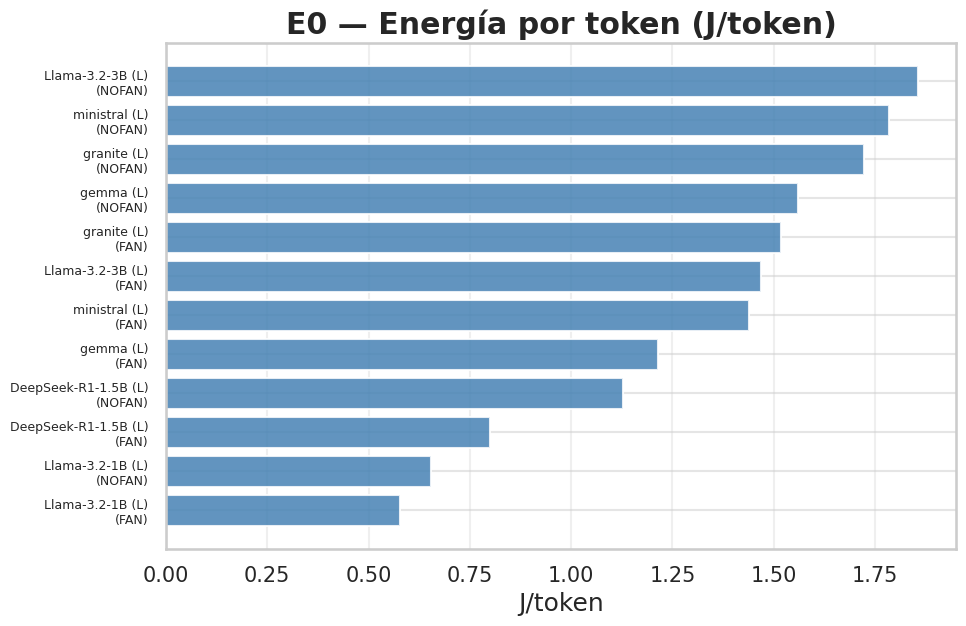

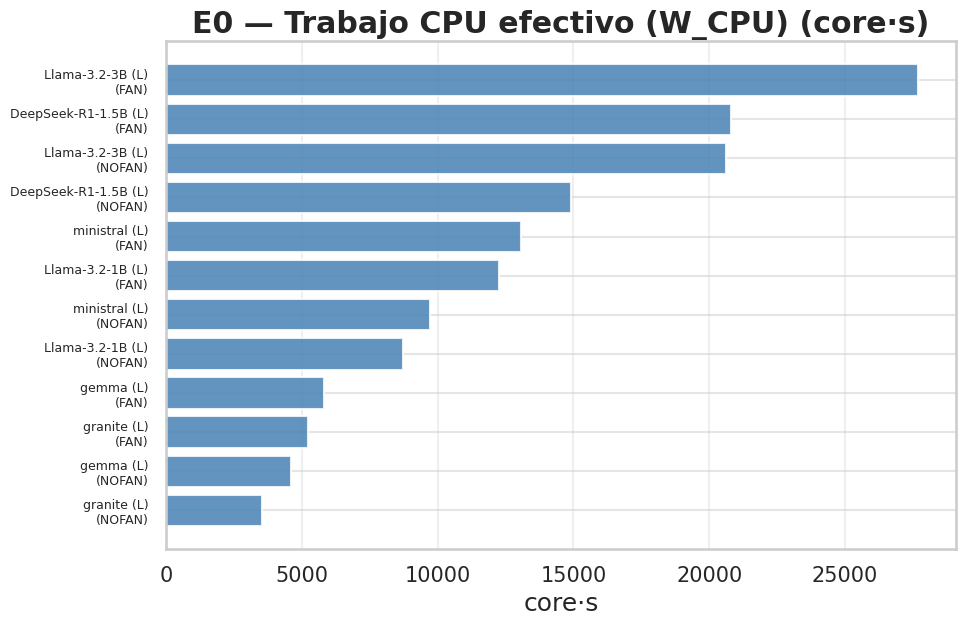

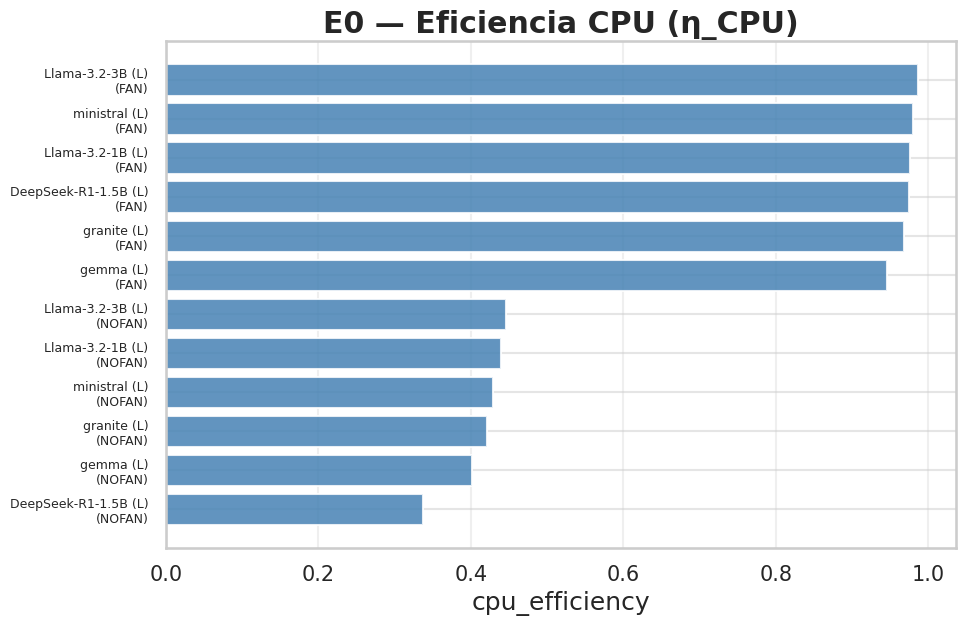

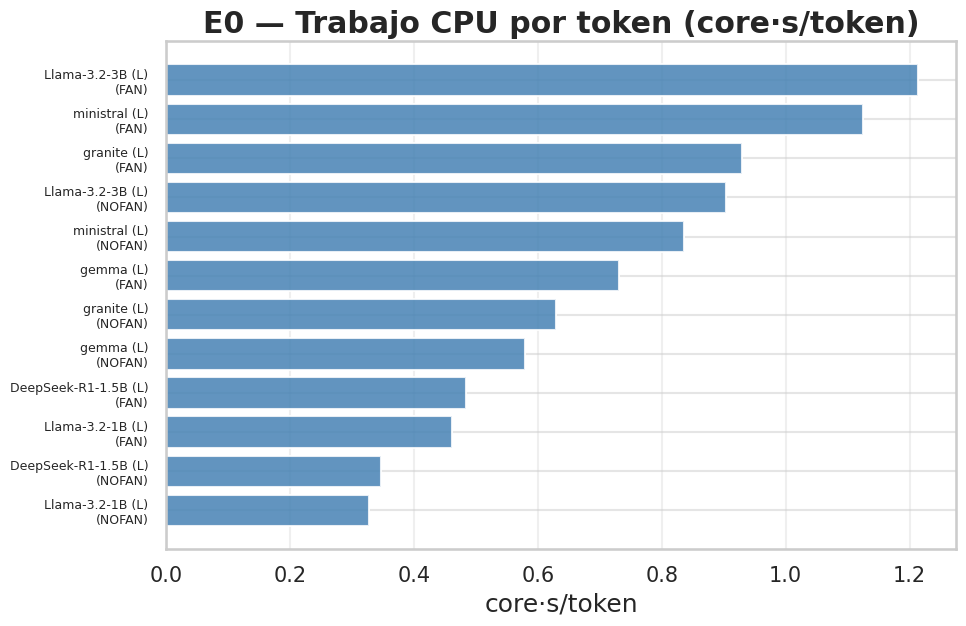

In [16]:
if not summary.empty:
    for metric, title, unit in [
        ('energy_per_token_j',  'Energía por token',           'J/token'),
        ('cpu_work_core_s',     'Trabajo CPU efectivo (W_CPU)', 'core·s'),
        ('cpu_efficiency',      'Eficiencia CPU (η_CPU)',       ''),
        ('cpu_work_per_token',  'Trabajo CPU por token',        'core·s/token'),
    ]:
        if metric in summary.columns:
            _plot_metric(summary, metric, ylabel=unit,
                         title=f'E0 \u2014 {title}', unit_label=unit)
        else:
            print(f'Métrica no disponible en summary: {metric}')
else:
    print('Sin datos de summary para eficiencia energética.')


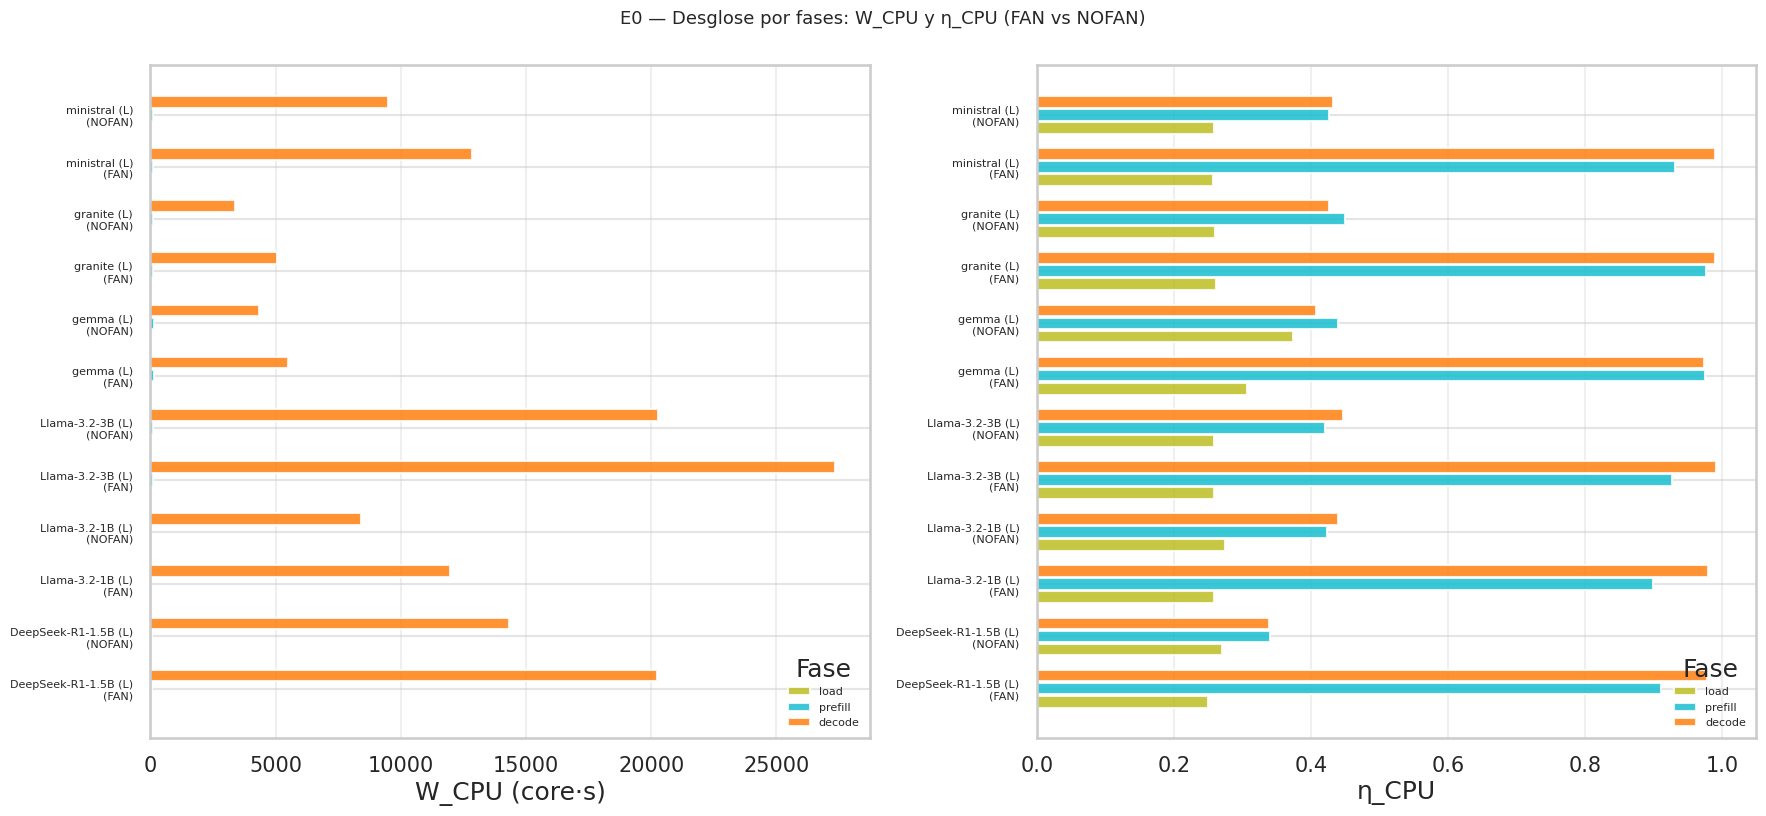

In [17]:
phase_df = coll.cpu_work_by_phase_df() if len(coll.runs) > 0 else pd.DataFrame()

if not phase_df.empty:
    if "run_id" in phase_df.columns:
        phase_df = phase_df.merge(
            summary[["run_id","config_label","fan"]].drop_duplicates(),
            on="run_id", how="left"
        )
    elif "model_label" in phase_df.columns and "fan" in phase_df.columns:
        phase_df = phase_df.merge(
            summary[["model_label","fan","config_label"]].drop_duplicates(),
            on=["model_label","fan"], how="left"
        )
    if "config_label" not in phase_df.columns:
        phase_df["config_label"] = phase_df.get("model_label", "?")

    PHASE_ORDER  = ["load","prefill","decode"]
    PHASE_COLORS = {"load":"#bcbd22","prefill":"#17becf","decode":"#ff7f0e"}
    configs = sorted(phase_df["config_label"].unique())
    y = np.arange(len(configs))
    width = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(configs) * 0.7)))
    for ax, (metric, xlabel, xlim) in zip(axes, [
        ("cpu_work_core_s", "W_CPU (core\u00b7s)", None),
        ("cpu_efficiency",  "\u03b7_CPU",           (0, 1.05)),
    ]):
        for i, phase in enumerate(PHASE_ORDER):
            sub  = phase_df[phase_df["phase"] == phase]
            vals = [sub[sub["config_label"] == c][metric].mean()
                    if c in sub["config_label"].values else float('nan')
                    for c in configs]
            ax.barh(y + (i - 1) * width, vals, width * 0.9,
                    label=phase, color=PHASE_COLORS[phase], alpha=0.85)
        ax.set_yticks(y)
        ax.set_yticklabels(configs, fontsize=8)
        ax.set_xlabel(xlabel)
        if xlim: ax.set_xlim(*xlim)
        ax.legend(title="Fase", loc="lower right", fontsize=8)
        ax.grid(True, axis='x', alpha=0.3)
    fig.suptitle("E0 \u2014 Desglose por fases: W_CPU y \u03b7_CPU (FAN vs NOFAN)", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print('Sin datos de fases de CPU work (requiere hw data con fases anotadas).')


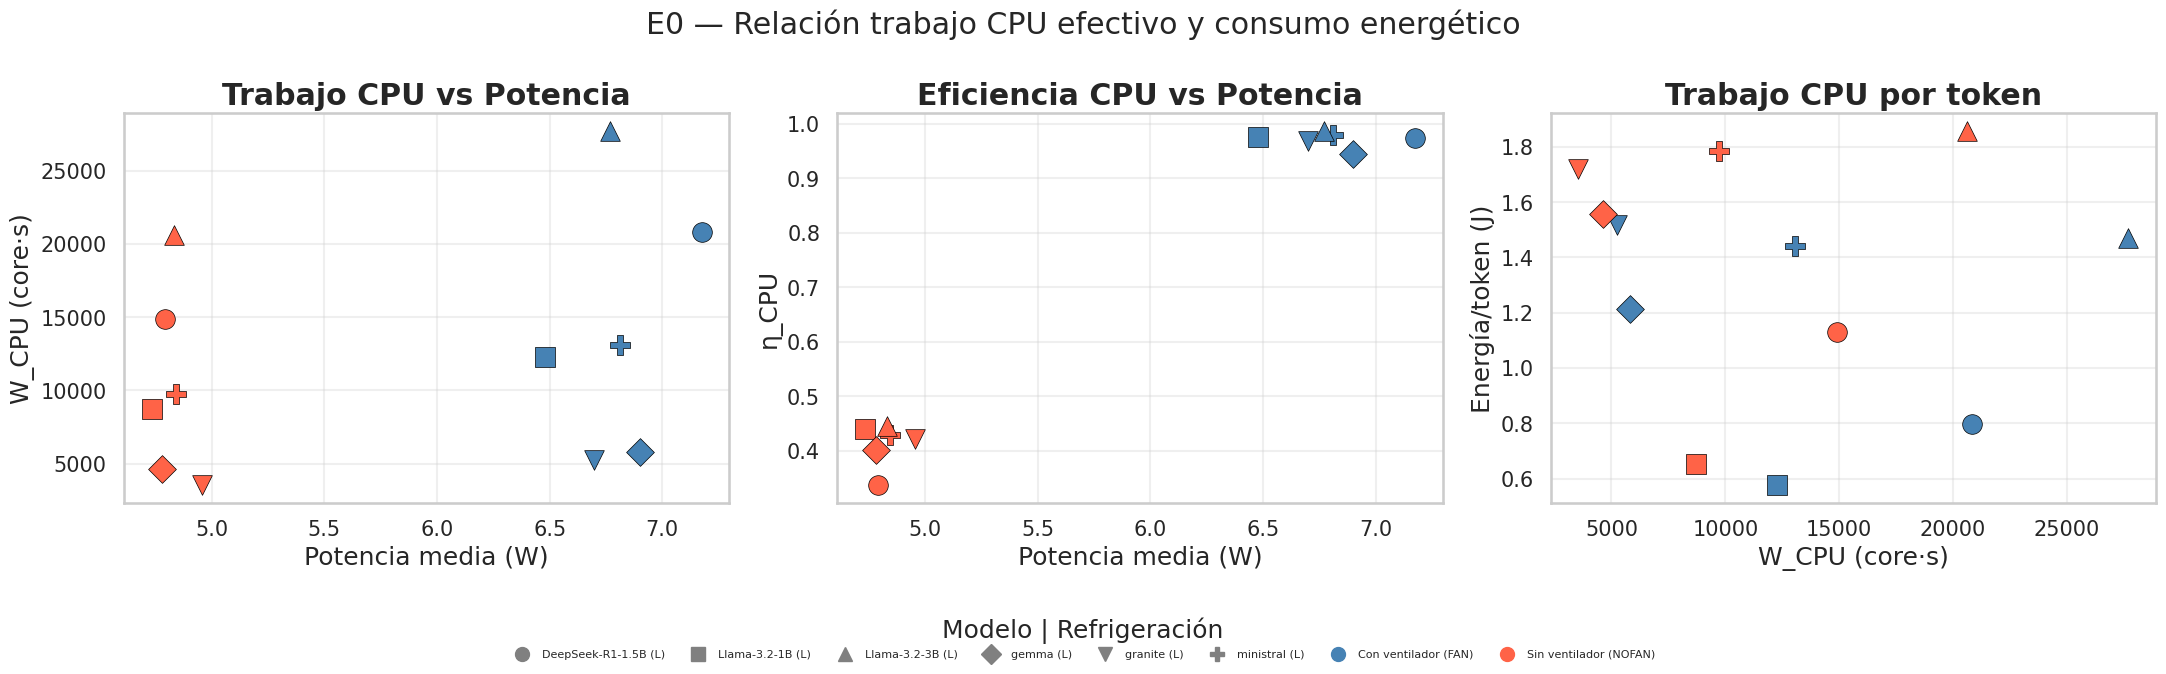

In [18]:
# Helpers de scatter reutilizables en el notebook
MARKERS    = ["o", "s", "^", "D", "v", "P", "*", "X", "h", "<"]
COLORS_FAN = {True: "steelblue", False: "tomato"}
LABELS_FAN = {True: "FAN", False: "NOFAN"}
OFFSETS    = [(5,5),(-5,-10),(10,-5),(-10,5),(5,-15),(-5,10),
              (15,0),(-15,0),(0,12),(-12,-5),(8,-8),(-8,8)]

def scatter_with_legend(ax, data, x, y, label_col="model_label", fan_col="fan"):
    models    = sorted(data[label_col].unique())
    marker_map = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}
    seen = set()
    for _, row in data.iterrows():
        model = row[label_col]; fan = row.get(fan_col, True); key = (model, fan)
        lbl = f"{model} ({LABELS_FAN.get(fan, str(fan))})" if key not in seen else None
        ax.scatter(row[x], row[y], marker=marker_map[model],
                   color=COLORS_FAN.get(fan, "gray"), s=150, zorder=3, label=lbl)
        seen.add(key)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8,
              title="Modelo (refrigeraci\u00f3n)", framealpha=0.9)
    ax.grid(True, alpha=0.3)

def scatter_cpu_energy(ax, df, x_col, y_col, x_label, y_label, title):
    models  = sorted(df["model_label"].unique())
    mk_map  = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}
    for idx, (_, row) in enumerate(df.iterrows()):
        if pd.isna(row.get(x_col)) or pd.isna(row.get(y_col)): continue
        m, fan = row["model_label"], row["fan"]
        ax.scatter(row[x_col], row[y_col],
                marker=mk_map[m], color=COLORS_FAN[fan],

                   s=200, zorder=3, edgecolors='black', linewidths=0.5)
        ox, oy = OFFSETS[idx % len(OFFSETS)]
        # ax.annotate(
        #     f"{m}\n({LABELS_FAN[fan]})",
        #     xy=(row[x_col], row[y_col]),
        #     xytext=(ox, oy), textcoords="offset points",
        #     fontsize=7, ha='center',
        #     arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        # )
    ax.set_xlabel(x_label); ax.set_ylabel(y_label)
    ax.set_title(title); ax.grid(True, alpha=0.3)

if not summary.empty:
    cpu_e = summary.dropna(subset=["cpu_work_core_s", "power_mean_w"]).copy()
    if not cpu_e.empty:
        fig, axes = plt.subplots(1, 3, figsize=(22, 6))
        scatter_cpu_energy(axes[0], cpu_e,
            "power_mean_w",    "cpu_work_core_s",
            "Potencia media (W)", "W_CPU (core\u00b7s)", "Trabajo CPU vs Potencia")
        scatter_cpu_energy(axes[1], cpu_e,
            "power_mean_w",    "cpu_efficiency",
            "Potencia media (W)", "\u03b7_CPU", "Eficiencia CPU vs Potencia")
        scatter_cpu_energy(axes[2], cpu_e,
            "cpu_work_core_s", "energy_per_token_j",
            "W_CPU (core\u00b7s)", "Energ\u00eda/token (J)", "Trabajo CPU por token")
        from matplotlib.lines import Line2D
        models = sorted(cpu_e["model_label"].unique())
        mk_map = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}
        legend_elements = (
            [Line2D([0],[0], marker=mk_map[m], color='gray',
                     markerfacecolor='gray', ms=10, label=m, linestyle='None')
             for m in models] +
            [Line2D([0],[0], marker='o', color=c, markerfacecolor=c,
                     ms=10, label=l, linestyle='None')
             for c, l in [("steelblue","Con ventilador (FAN)"),
                           ("tomato",  "Sin ventilador (NOFAN)")]]
        )
        fig.legend(handles=legend_elements, loc='lower center',
                   ncol=len(models)+2, fontsize=8,
                   bbox_to_anchor=(0.5, -0.12), title="Modelo | Refrigeraci\u00f3n")
        fig.suptitle("E0 \u2014 Relaci\u00f3n trabajo CPU efectivo y consumo energ\u00e9tico")
        fig.tight_layout(); plt.show()
    else:
        print('Sin datos suficientes para gr\u00e1ficas de CPU vs Potencia.')
else:
    print('Sin datos de summary para an\u00e1lisis CPU vs Potencia.')


## 6. Rendimiento combinado y utilización de hardware

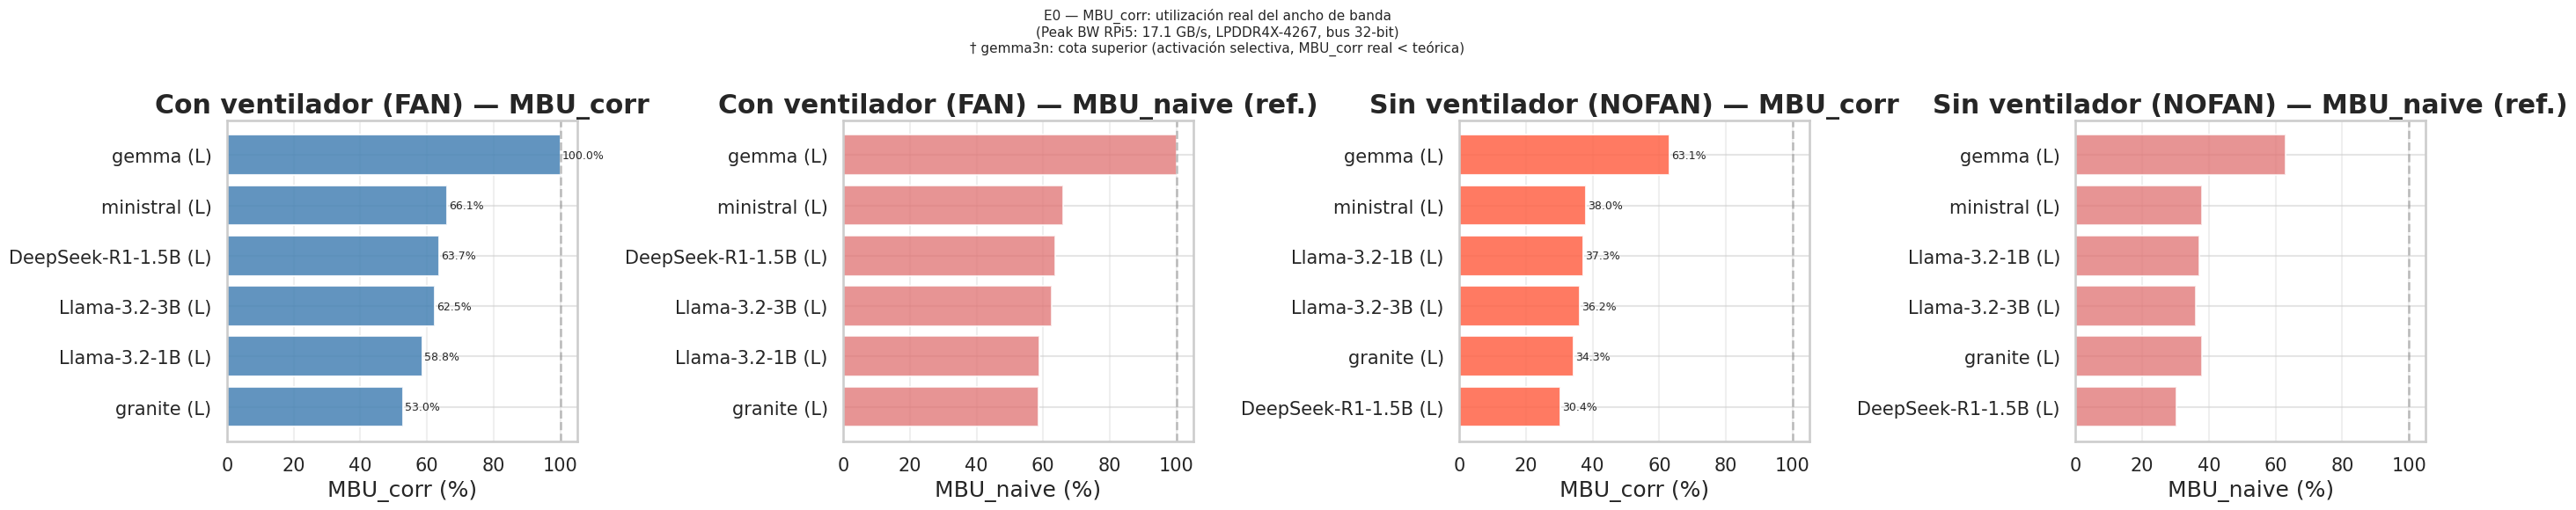

Correcciones aplicadas:


,model_label,mbu_naive,mbu_corr,mbu_corr_notes
0,ministral (L),66.13,66.13,dense
1,Llama-3.2-3B (L),62.46,62.46,dense
2,Llama-3.2-1B (L),58.78,58.78,dense
3,granite (L),58.74,52.96,"Granite SSM hybrid: M_state=74.4 MiB, L_ssm=36..."
4,gemma (L),100.00,100.00,Gemma 3n MatFormer: N_params_act desconocido —...
5,DeepSeek-R1-1.5B (L),63.65,63.65,dense


In [19]:
# MBU_corr — Memory Bandwidth Utilization (arquitectura corregida)
from monitorviz.viz.style import TARGET_PEAK_MEMORY_BANDWIDTH_GBs

_mbu_col   = "mbu_corr"  if "mbu_corr"  in summary.columns else "mbu_pct"
_naive_col = "mbu_naive" if "mbu_naive" in summary.columns else None

if _mbu_col in summary.columns:
    mbu_data = summary.dropna(subset=[_mbu_col]).copy()
    if not mbu_data.empty:
        has_diff = (
            _naive_col is not None and _naive_col in mbu_data.columns
            and (mbu_data[_naive_col] - mbu_data[_mbu_col]).abs().max() > 0.1
        )
        has_fan = "fan" in mbu_data.columns and mbu_data["fan"].nunique() > 1
        fan_groups = ([(True, "Con ventilador (FAN)", "steelblue"),
                       (False, "Sin ventilador (NOFAN)", "tomato")]
                      if has_fan else [(None, "Todos los runs", "steelblue")])
        ncols = len(fan_groups) * (2 if has_diff else 1)
        fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6), sharey=False)
        if ncols == 1:
            axes = [axes]
        col_idx = 0
        for fan_val, label, color in fan_groups:
            sub = (mbu_data[mbu_data["fan"] == fan_val] if fan_val is not None else mbu_data).copy()
            sub = sub.sort_values(_mbu_col)
            if sub.empty:
                axes[col_idx].set_axis_off(); col_idx += 1; continue
            axes[col_idx].barh(sub["model_label"], sub[_mbu_col], color=color, alpha=0.85)
            axes[col_idx].axvline(100, ls="--", color="gray", alpha=0.5)
            axes[col_idx].set_xlabel("MBU_corr (%)")
            axes[col_idx].set_title(f"{label} — MBU_corr")
            axes[col_idx].grid(True, axis="x", alpha=0.3)
            for bar, val in zip(axes[col_idx].patches, sub[_mbu_col]):
                axes[col_idx].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                                   f"{val:.1f}%", va="center", fontsize=9)
            col_idx += 1
            if has_diff and _naive_col in sub.columns:
                axes[col_idx].barh(sub["model_label"], sub[_naive_col], color="#e07070", alpha=0.75)
                axes[col_idx].axvline(100, ls="--", color="gray", alpha=0.5)
                axes[col_idx].set_xlabel("MBU_naive (%)")
                axes[col_idx].set_title(f"{label} — MBU_naive (ref.)")
                axes[col_idx].grid(True, axis="x", alpha=0.3)
                col_idx += 1
        fig.suptitle(
            f"E0 — MBU_corr: utilización real del ancho de banda\n"
            f"(Peak BW RPi5: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s, LPDDR4X-4267, bus 32-bit)\n"
            "† gemma3n: cota superior (activación selectiva, MBU_corr real < teórica)",
            fontsize=11)
        plt.tight_layout()
        plt.show()
        if "mbu_corr_notes" in mbu_data.columns:
            notes = (
                mbu_data[["model_label", "mbu_naive", "mbu_corr", "mbu_corr_notes"]]
                .drop_duplicates("model_label").round(2)
            )
            print("Correcciones aplicadas:")
            display(notes)
    else:
        print("Sin datos de MBU disponibles.")
else:
    print("Sin columna mbu_corr — regenera summary_df()")


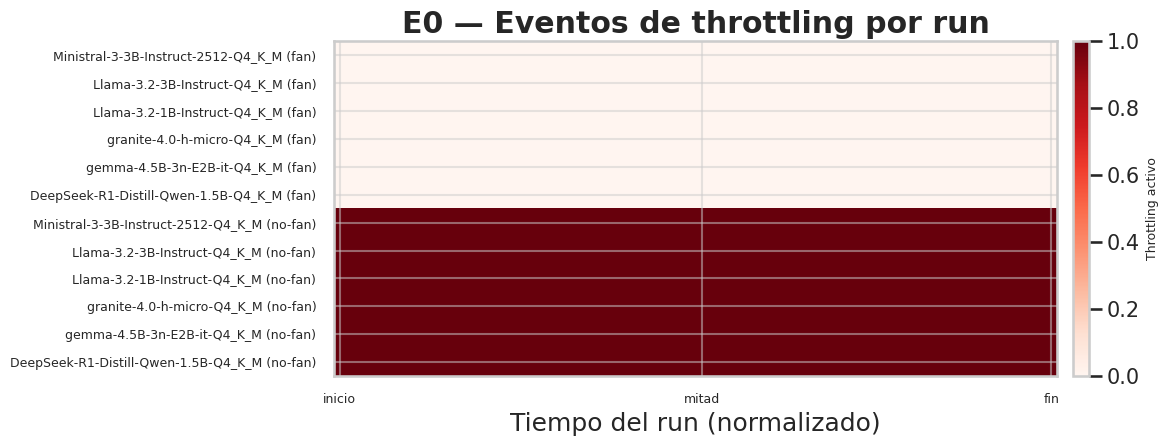

In [20]:
if not hw_df.empty:
    runs_con_hw = [r for r in coll.runs
                   if not hw_df[hw_df['run_id'] == r.run_id].empty]
    if runs_con_hw:
        try:
            fig = throttling_heatmap(hw_df, runs_con_hw,
                                     title='E0 \u2014 Eventos de throttling por run')
            plt.show()
        except Exception as e:
            print(f'throttling_heatmap: {e}')
    else:
        print('Sin runs con datos de hardware para throttling heatmap.')
else:
    print('Sin datos de hardware para throttling heatmap.')


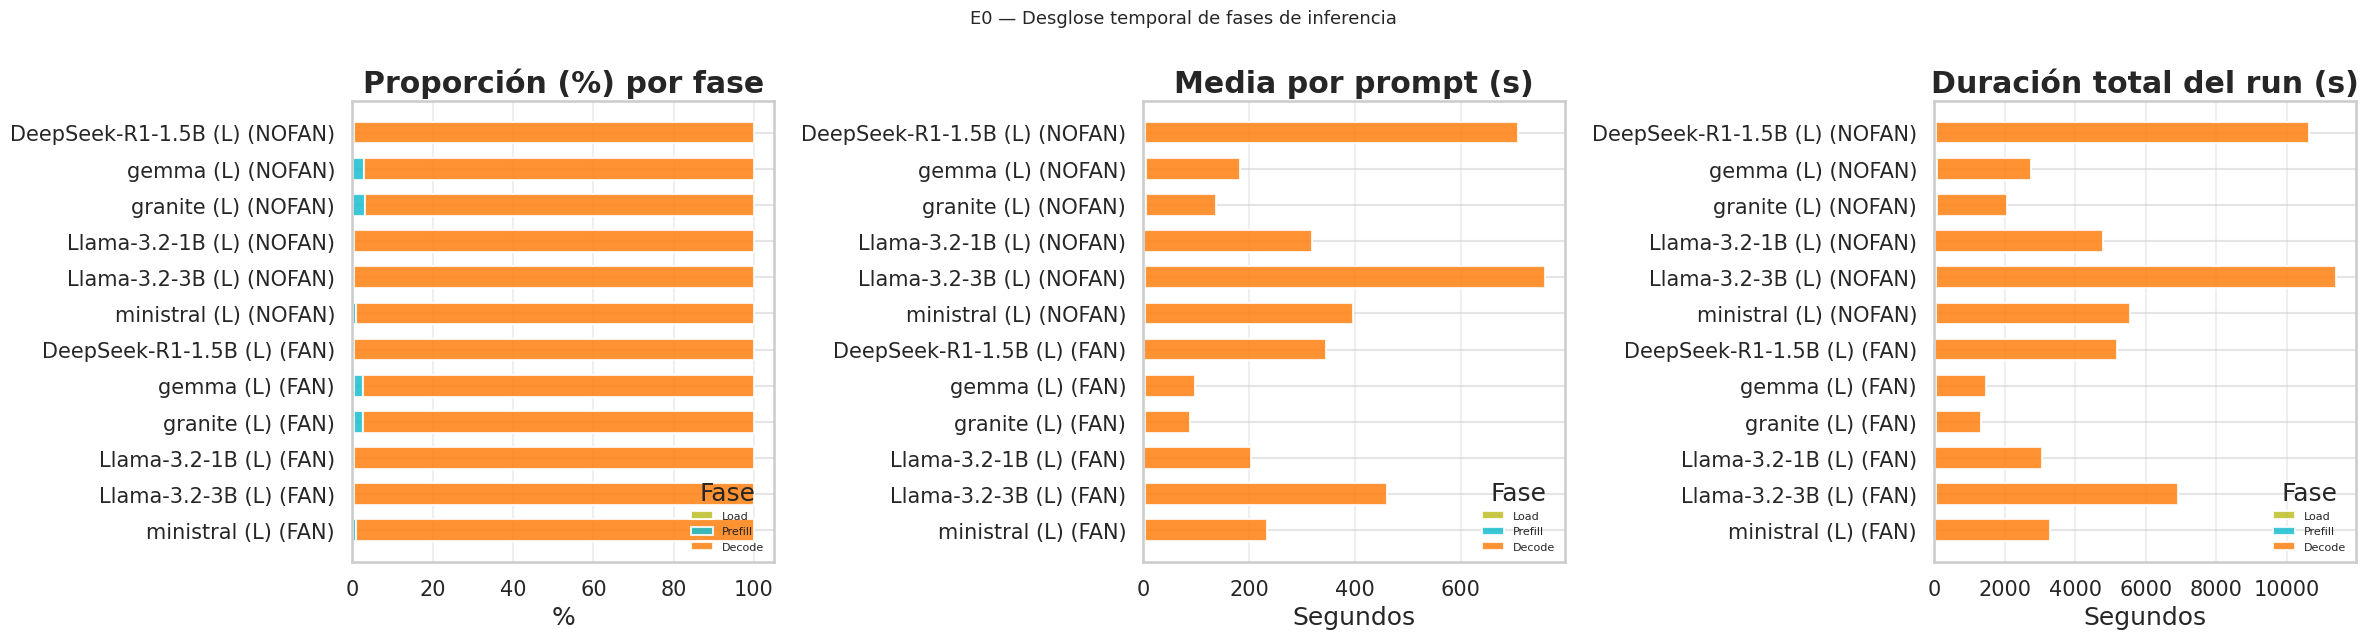

In [21]:
if not summary.empty:
    phase_cols = {}
    for run in coll.runs:
        rid   = run.run_id
        label = summary.loc[summary["run_id"] == rid, "model_label"].values
        fan   = summary.loc[summary["run_id"] == rid, "fan"].values
        if len(label) == 0: continue
        non_empty = [p for p in run.prompts if not p.is_empty_generation]
        if not non_empty: continue
        phase_cols.setdefault("model_label", []).append(label[0])
        phase_cols.setdefault("fan",         []).append(fan[0])
        # Media por prompt
        phase_cols.setdefault("load_s",      []).append(
            np.mean([p.load_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("prefill_s",   []).append(
            np.mean([p.prompt_eval_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("decode_s",    []).append(
            np.mean([p.eval_duration_ns / 1e9 for p in non_empty]))
        # Total del run (suma sobre todos los prompts)
        phase_cols.setdefault("load_total_s",    []).append(
            np.sum([p.load_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("prefill_total_s", []).append(
            np.sum([p.prompt_eval_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("decode_total_s",  []).append(
            np.sum([p.eval_duration_ns / 1e9 for p in non_empty]))

    phase_df2 = pd.DataFrame(phase_cols)
    if not phase_df2.empty:
        phase_df2["config"] = (
            phase_df2["model_label"] + " (" +
            phase_df2["fan"].map({True: "FAN", False: "NOFAN"}) + ")"
        )

    PHASES       = ["load_s",       "prefill_s",       "decode_s"]
    PHASES_TOTAL = ["load_total_s", "prefill_total_s", "decode_total_s"]
    LABELS  = {"load_s": "Load", "prefill_s": "Prefill", "decode_s": "Decode",
               "load_total_s": "Load", "prefill_total_s": "Prefill", "decode_total_s": "Decode"}
    COLORS  = {"load_s": "#bcbd22", "prefill_s": "#17becf", "decode_s": "#ff7f0e",
               "load_total_s": "#bcbd22", "prefill_total_s": "#17becf", "decode_total_s": "#ff7f0e"}

    if not phase_df2.empty:
        n_configs = len(phase_df2)
        fig, axes = plt.subplots(1, 3, figsize=(24, max(5, n_configs * 0.55)))

        # Panel 1: Proporci\u00f3n (%) — usa totales para la proporci\u00f3n real
        ax = axes[0]
        total_run = phase_df2[PHASES_TOTAL].sum(axis=1)
        left = np.zeros(n_configs)
        for ph, ph_t in zip(PHASES, PHASES_TOTAL):
            vals = phase_df2[ph_t] / total_run * 100
            ax.barh(phase_df2["config"], vals, left=left,
                    label=LABELS[ph], color=COLORS[ph], alpha=0.85, height=0.6)
            left += vals.to_numpy()
        ax.set_title("Proporci\u00f3n (%) por fase")
        ax.set_xlim(0, 105); ax.set_xlabel("%")
        ax.set_ylabel(""); ax.legend(title="Fase", loc="lower right", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

        # Panel 2: Media por prompt (s)
        ax = axes[1]
        left = np.zeros(n_configs)
        for ph in PHASES:
            ax.barh(phase_df2["config"], phase_df2[ph], left=left,
                    label=LABELS[ph], color=COLORS[ph], alpha=0.85, height=0.6)
            left += phase_df2[ph].to_numpy()
        ax.set_title("Media por prompt (s)")
        ax.set_xlabel("Segundos"); ax.set_ylabel("")
        ax.legend(title="Fase", loc="lower right", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

        # Panel 3: Total del run (s)
        ax = axes[2]
        left = np.zeros(n_configs)
        for ph_t in PHASES_TOTAL:
            ax.barh(phase_df2["config"], phase_df2[ph_t], left=left,
                    label=LABELS[ph_t], color=COLORS[ph_t], alpha=0.85, height=0.6)
            left += phase_df2[ph_t].to_numpy()
        ax.set_title("Duraci\u00f3n total del run (s)")
        ax.set_xlabel("Segundos"); ax.set_ylabel("")
        ax.legend(title="Fase", loc="lower right", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

        fig.suptitle("E0 \u2014 Desglose temporal de fases de inferencia", fontsize=13)
        fig.tight_layout(); plt.show()
    else:
        print("Sin datos de fases.")
else:
    print("Sin datos de summary para desglose de fases.")
    phase_df2 = pd.DataFrame()
    PHASES = []; PHASES_TOTAL = []; COLORS = {}


In [22]:
if not phase_df2.empty and "power_mean_w" in summary.columns:
    merged = phase_df2.merge(
        summary[["model_label", "fan", "power_mean_w"]],
        on=["model_label", "fan"], how="left"
    )
    # Energía = potencia media × duración total de cada fase
    for ph, ph_t in zip(PHASES, PHASES_TOTAL):
        merged[ph.replace("_s", "_mean_j")] = merged["power_mean_w"] * merged[ph]
        merged[ph_t.replace("_total_s", "_total_j")] = merged["power_mean_w"] * merged[ph_t]

    result_rows = []
    for model in sorted(merged["model_label"].unique()):
        row = {"Modelo": model}
        for fan_val, fan_label in [(True, "FAN"), (False, "NOFAN")]:
            sub = merged[(merged["model_label"] == model) & (merged["fan"] == fan_val)]
            if sub.empty:
                continue
            for ph_base, ph_label in [("load", "Load"), ("prefill", "Prefill"), ("decode", "Decode")]:
                row[f"{ph_label} s/prompt ({fan_label})"] = sub[f"{ph_base}_s"].values[0]
                row[f"{ph_label} s total ({fan_label})"]  = sub[f"{ph_base}_total_s"].values[0]
                row[f"{ph_label} J total ({fan_label})"]  = sub[f"{ph_base}_total_j"].values[0]
        result_rows.append(row)

    result = pd.DataFrame(result_rows).round(2)
    print("E0 \u2014 Duraci\u00f3n y energ\u00eda por fase (s/prompt = media; total = suma del run)")
    display(result)


E0 — Duración y energía por fase (s/prompt = media; total = suma del run)


,Modelo,Load s/prompt (FAN),Load s total (FAN),Load J total (FAN),Prefill s/prompt (FAN),Prefill s total (FAN),Prefill J total (FAN),Decode s/prompt (FAN),Decode s total (FAN),Decode J total (FAN),Load s/prompt (NOFAN),Load s total (NOFAN),Load J total (NOFAN),Prefill s/prompt (NOFAN),Prefill s total (NOFAN),Prefill J total (NOFAN),Decode s/prompt (NOFAN),Decode s total (NOFAN),Decode J total (NOFAN)
0,DeepSeek-R1-1.5B (L),0.09,1.32,9.46,0.86,12.95,92.93,344.84,5172.61,37116.22,0.09,1.39,6.67,2.30,34.47,165.22,707.24,10608.53,50847.76
1,Llama-3.2-1B (L),0.06,0.92,5.97,0.61,9.17,59.39,203.49,3052.33,19777.22,0.06,0.93,4.41,1.15,17.28,81.79,318.51,4777.68,22614.48
2,Llama-3.2-3B (L),0.18,2.68,18.15,1.76,26.43,178.93,459.79,6896.82,46682.66,0.19,2.84,13.75,3.53,52.92,255.74,756.07,11341.12,54805.54
3,gemma (L),0.29,4.28,29.56,2.33,34.91,240.88,94.05,1410.78,9734.13,0.31,4.71,22.53,4.85,72.76,347.87,176.90,2653.51,12685.83
4,granite (L),0.25,3.70,24.75,2.10,31.53,211.19,85.17,1277.58,8557.09,0.26,3.93,19.49,3.96,59.47,294.82,132.34,1985.11,9840.37
5,ministral (L),0.22,3.05,20.80,1.71,23.95,163.17,231.70,3243.76,22099.57,0.24,3.35,16.24,3.46,48.49,234.85,393.13,5503.80,26653.47


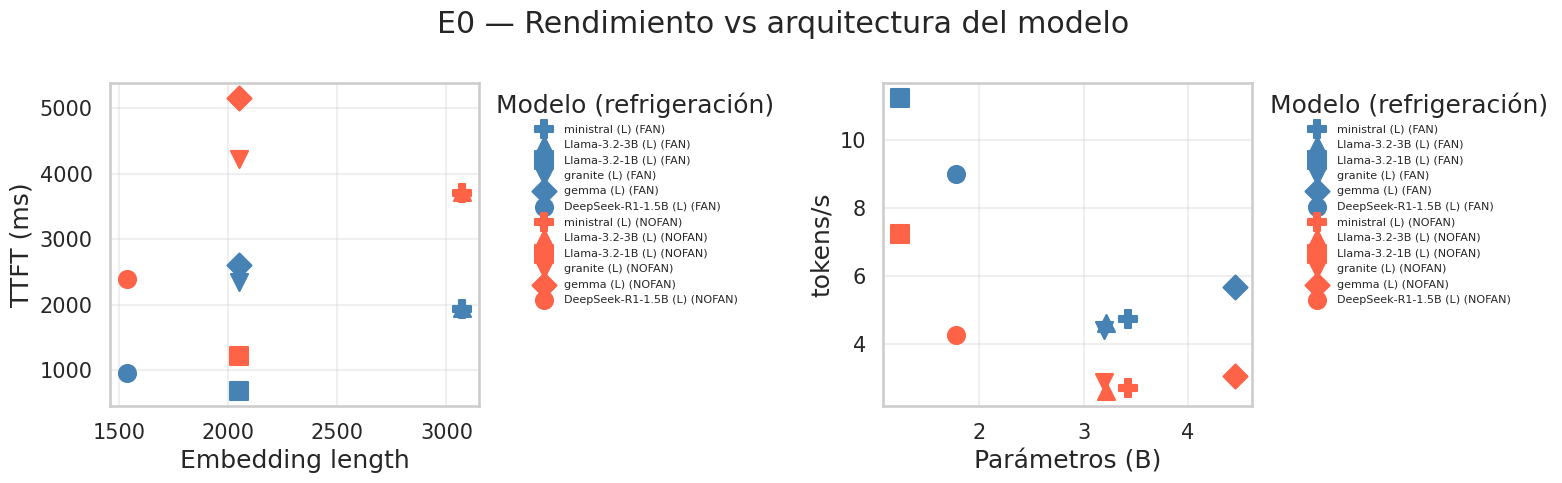

In [23]:
if not summary.empty:
    run_map = {r.run_id: r for r in coll.runs}
    n_params_list, emb_len_list = [], []
    for rid in summary['run_id']:
        r = run_map.get(rid)
        mi = (r.summary.model_info or {}) if r else {}
        n_params_list.append(mi.get('n_params', float('nan')))
        emb_len_list.append(mi.get('embedding_length', float('nan')))
    summary_arch = summary.copy()
    summary_arch['n_params_b'] = pd.array(n_params_list, dtype='float64') / 1e9
    summary_arch['emb_len']    = pd.array(emb_len_list, dtype='float64')

    arch = summary_arch.dropna(subset=['n_params_b', 'emb_len'])
    if not arch.empty:
        plot_triples = [
            ('emb_len',    'ttft_ms_mean',      'Embedding length', 'TTFT (ms)'),
            ('n_params_b', 'tokens_per_s_mean', 'Par\u00e1metros (B)', 'tokens/s'),
            ('n_params_b', 'ttlm_ms',           'Par\u00e1metros (B)', 'TTLM (ms)'),
        ]
        plot_triples = [(x, y, xl, yl) for x, y, xl, yl in plot_triples
                        if y in arch.columns]
        if plot_triples:
            fig, axes = plt.subplots(1, len(plot_triples),
                                     figsize=(8 * len(plot_triples), 5))
            if len(plot_triples) == 1:
                axes = [axes]
            for ax, (x, y, xl, yl) in zip(axes, plot_triples):
                scatter_with_legend(ax, arch, x, y)
                ax.set_xlabel(xl)
                ax.set_ylabel(yl)
            fig.suptitle('E0 \u2014 Rendimiento vs arquitectura del modelo')
            plt.tight_layout()
            plt.show()
    else:
        print('Sin model_info disponible para gr\u00e1ficas de arquitectura.')
else:
    print('Sin datos de summary para an\u00e1lisis de arquitectura.')


## 7. Trade-offs y análisis multidimensional

Columnas normalizadas por parámetros:
             model_label    n_params  tokens_per_s_mean  tok_s_per_Mparam  energy_per_token_j  j_token_x_Mparam
0          ministral (L)  3429006336             4.7313            0.0014              1.4400         4937.6820
1       Llama-3.2-3B (L)  3212749888             4.6081            0.0014              1.4689         4719.1773
2       Llama-3.2-1B (L)  1235814432            11.2293            0.0091              0.5770          713.0757
3            granite (L)  3191396096             4.4099            0.0014              1.5188         4847.2171
4              gemma (L)  4458122848             5.6829            0.0013              1.2141         5412.7600
5   DeepSeek-R1-1.5B (L)  1777088000             8.9783            0.0051              0.7992         1420.2608
6          ministral (L)  3429006336             2.7142            0.0008              1.7842         6118.0814
7       Llama-3.2-3B (L)  3212749888             2.6020           

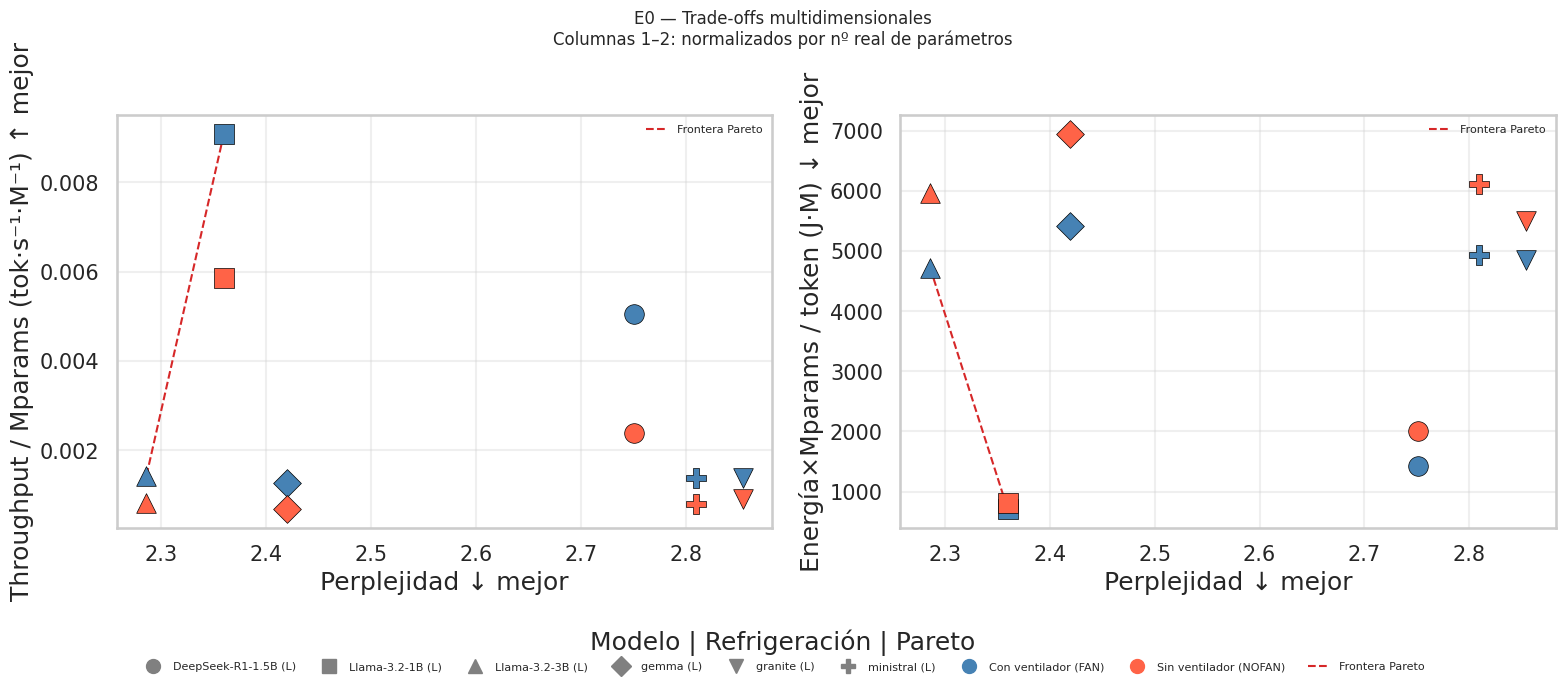

In [24]:
def _pareto_front(df, x_col, y_col, x_lower, y_lower):
    """Devuelve las filas en la frontera de Pareto."""
    pts = df[[x_col, y_col]].to_numpy()
    n = len(pts)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            x_ok = (pts[j,0] <= pts[i,0]) if x_lower else (pts[j,0] >= pts[i,0])
            y_ok = (pts[j,1] <= pts[i,1]) if y_lower else (pts[j,1] >= pts[i,1])
            strict = (pts[j,0] != pts[i,0]) or (pts[j,1] != pts[i,1])
            if x_ok and y_ok and strict:
                dominated[i] = True; break
    return df[~dominated].sort_values(x_col)

if not summary.empty:
    # ── Métricas normalizadas por número real de parámetros ──────────────────
    # Se escala a "por millón de parámetros" (÷1e6) para mantener
    # los valores del eje en rango legible manteniendo la precisión real.
    if "n_params" in summary.columns and summary["n_params"].notna().any():
        n_M = summary["n_params"] / 1e6

        # tok/s por millón de parámetros (↑ mejor)
        summary["tok_s_per_Mparam"] = summary["tokens_per_s_mean"] / n_M

        # J/token × millones de parámetros (↓ mejor)
        summary["j_token_x_Mparam"] = summary["energy_per_token_j"] * n_M

        print("Columnas normalizadas por parámetros:")
        print(
            summary[["model_label", "n_params", "tokens_per_s_mean",
                      "tok_s_per_Mparam", "energy_per_token_j", "j_token_x_Mparam"]]
            .round(4)
        )
    else:
        print("n_params no disponible; se omiten pares normalizados del Pareto.")

    PAIRS = [
        # ── Bloque A: valores ABSOLUTOS ──────────────────────────────────────
        # (
        #     "perplexity_geomean", "tokens_per_s_mean",
        #     "Perplejidad ↓ mejor", "Throughput (tok/s) ↑ mejor",
        #     True, False,
        # ),
        # (
        #     "perplexity_geomean", "energy_per_token_j",
        #     "Perplejidad ↓ mejor", "Energía/token (J) ↓ mejor",
        #     True, True,
        # ),
        # (
        #     "power_mean_w", "tokens_per_s_mean",
        #     "Potencia media (W) ↓ mejor", "Throughput (tok/s) ↑ mejor",
        #     True, False,
        # ),
        # ── Bloque B: valores NORMALIZADOS por nº real de parámetros ─────────
        (
            "perplexity_geomean", "tok_s_per_Mparam",
            "Perplejidad ↓ mejor", "Throughput / Mparams (tok·s⁻¹·M⁻¹) ↑ mejor",
            True, False,
        ),
        (
            "perplexity_geomean", "j_token_x_Mparam",
            "Perplejidad ↓ mejor", "Energía×Mparams / token (J·M) ↓ mejor",
            True, True,
        ),
    ]

    pairs = [
        (x, y, xl, yl, xb, yb)
        for x, y, xl, yl, xb, yb in PAIRS
        if x in summary.columns and y in summary.columns
        and summary[[x, y]].dropna().shape[0] >= 2
    ]

    n_abs  = sum(1 for p in pairs if "Mparam" not in p[3])
    n_norm = sum(1 for p in pairs if "Mparam"     in p[3])
    print(f"Pares Pareto: {n_abs} absolutos + {n_norm} normalizados = {len(pairs)} total")

    if pairs:
        from matplotlib.lines import Line2D
        ncols = len(pairs)
        fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 6))
        if ncols == 1: axes = [axes]

        models = sorted(summary["model_label"].unique())
        mk_map = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}

        for ax, (x_col, y_col, x_label, y_label, x_lower, y_lower) in zip(axes, pairs):
            data = summary.dropna(subset=[x_col, y_col]).copy().reset_index(drop=True)
            if data.empty:
                ax.set_visible(False); continue

            for idx, (_, row) in enumerate(data.iterrows()):
                m, fan = row["model_label"], row["fan"]
                ax.scatter(row[x_col], row[y_col],
                           marker=mk_map[m], color=COLORS_FAN[fan],
                           s=200, zorder=3, edgecolors='black', linewidths=0.5)

            front = _pareto_front(data, x_col, y_col, x_lower, y_lower)
            ax.plot(front[x_col], front[y_col],
                    color="tab:red", lw=1.5, ls="--", zorder=2,
                    label="Frontera Pareto")
            ax.legend(fontsize=8, loc="best")

            # Labels ya incluyen ↓/↑ mejor — no añadir de nuevo
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            ax.grid(True, alpha=0.3)

        legend_elements = (
            [Line2D([0],[0], marker=mk_map[m], color='gray',
                     markerfacecolor='gray', ms=10, label=m, linestyle='None')
             for m in models] +
            [Line2D([0],[0], marker='o', color=c, markerfacecolor=c,
                     ms=10, label=l, linestyle='None')
             for c, l in [("steelblue", "Con ventilador (FAN)"),
                           ("tomato",   "Sin ventilador (NOFAN)")]] +
            [Line2D([0],[0], color='tab:red', lw=1.5, ls='--',
                     label='Frontera Pareto')]
        )
        fig.legend(handles=legend_elements, loc='lower center',
                   ncol=len(models) + 3, fontsize=8,
                   bbox_to_anchor=(0.5, -0.10),
                   title="Modelo | Refrigeración | Pareto")
        fig.suptitle(
            "E0 — Trade-offs multidimensionales\n"
            # f"Columnas 1–{n_abs}: valores absolutos  |  "
            f"Columnas {n_abs+1}–{ncols}: normalizados por nº real de parámetros",
            fontsize=12, y=1.02,
        )
        plt.tight_layout(); plt.show()
    else:
        print('Columnas insuficientes para Pareto.')
else:
    print('Sin datos de summary para Pareto.')


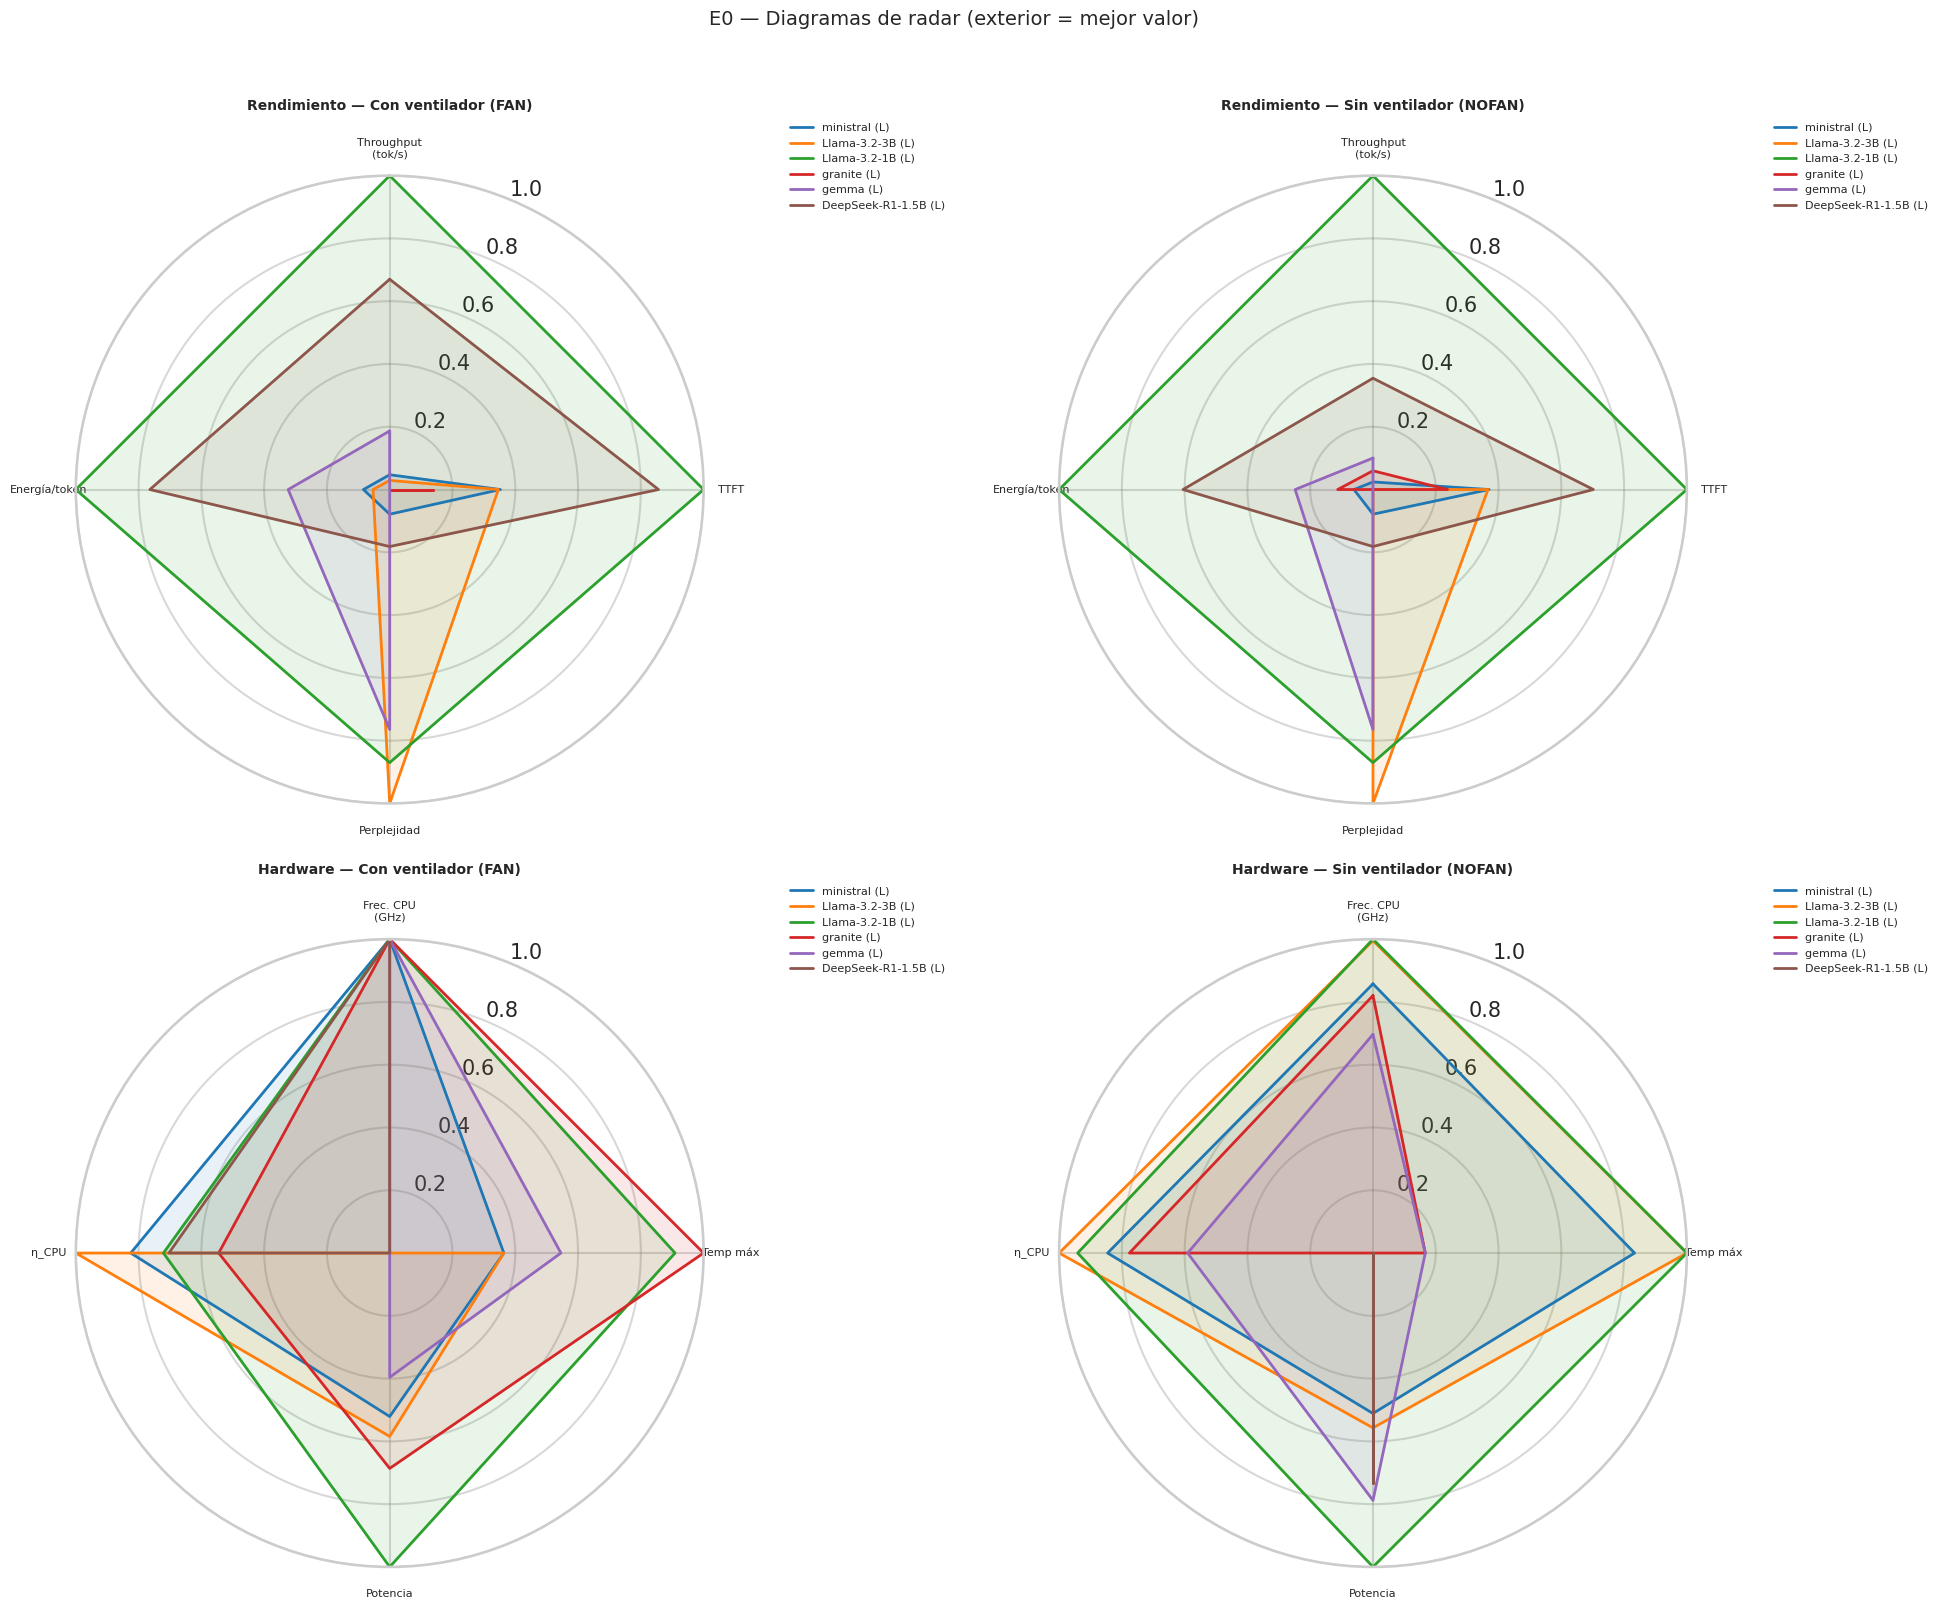

In [25]:
def _radar_chart(ax, df, metrics, title, colors):
    """Radar chart sobre un eje polar."""
    cols             = [m[0] for m in metrics]
    labels           = [m[1] for m in metrics]
    higher_is_better = [m[2] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.set_title(f"{title}\n(sin datos)", pad=15)
        return
    N      = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=8)
    ax.set_ylim(0, 1)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=20, fontsize=10, fontweight="bold")
    for col, hib in zip(cols, higher_is_better):
        mn, mx = data[col].min(), data[col].max()
        rng = mx - mn if mx != mn else 1.0
        data[f"_n_{col}"] = (data[col] - mn) / rng if hib else (mx - data[col]) / rng
    for i, (_, row) in enumerate(data.iterrows()):
        vals = [row[f"_n_{c}"] for c in cols] + [row[f"_n_{cols[0]}"]]
        ax.plot(angles, vals, lw=2, color=colors[i % len(colors)],
                label=row["model_label"])
        ax.fill(angles, vals, alpha=0.10, color=colors[i % len(colors)])
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)

if not summary.empty:
    PERF_METRICS = [
        ("tokens_per_s_mean",  "Throughput\n(tok/s)", True),
        ("ttft_ms_mean",       "TTFT",                False),
        ("perplexity_geomean", "Perplejidad",          False),
        ("energy_per_token_j", "Energía/token",        False),
    ]
    HW_METRICS = [
        ("freq_mean_inference_ghz", "Frec. CPU\n(GHz)", True),   # ↑ mejor: menos throttling
        ("temp_max_c",              "Temp máx",          False),  # ↓ mejor
        ("power_mean_w",            "Potencia",          False),  # ↓ mejor
        ("cpu_efficiency",          "η_CPU",             True),   # ↑ mejor
    ]
    COLORS_R = [f"C{i}" for i in range(10)]

    s_fan   = summary[summary["fan"] == True].copy()
    s_nofan = summary[summary["fan"] == False].copy()

    fig = plt.figure(figsize=(20, 16))
    panels = [
        (221, s_fan,   PERF_METRICS, "Rendimiento — Con ventilador (FAN)"),
        (222, s_nofan, PERF_METRICS, "Rendimiento — Sin ventilador (NOFAN)"),
        (223, s_fan,   HW_METRICS,   "Hardware — Con ventilador (FAN)"),
        (224, s_nofan, HW_METRICS,   "Hardware — Sin ventilador (NOFAN)"),
    ]
    for pos, data, metrics, title in panels:
        ax = fig.add_subplot(pos, polar=True)
        avail = [(c, l, h) for c, l, h in metrics if c in data.columns]
        _radar_chart(ax, data, avail, title, COLORS_R)

    fig.suptitle("E0 — Diagramas de radar (exterior = mejor valor)",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Sin datos para diagramas polares.')


In [26]:
if not summary.empty:
    compare_cols = [c for c in [
        "model_label", "fan",
        "tokens_per_s_mean",
        "words_per_s_mean",
        "perplexity_geomean",
        "energy_per_token_j",
        "temp_max_c",
        "throttled_ratio",
    ] if c in summary.columns]

    table = (summary[compare_cols]
             .sort_values(["model_label", "fan"])
             .round(3)
             .copy())
    table["fan"] = table["fan"].map({True: "FAN \u2713", False: "NOFAN \u2717"})
    table.columns = [c.replace("_mean", "").replace("_", " ") for c in table.columns]
    display(table.reset_index(drop=True))
else:
    print('Sin datos de summary para tabla comparativa.')


,model label,fan,tokens per s,words per s,perplexity geomean,energy per token j,temp max c,throttled ratio
0,DeepSeek-R1-1.5B (L),NOFAN ✗,4.245,3.458,2.751,1.129,96.35,1.000
1,DeepSeek-R1-1.5B (L),FAN ✓,8.978,7.312,2.751,0.799,75.45,0.000
2,Llama-3.2-1B (L),NOFAN ✗,7.236,5.567,2.360,0.654,93.05,0.999
3,Llama-3.2-1B (L),FAN ✓,11.229,8.657,2.360,0.577,69.95,0.000
4,Llama-3.2-3B (L),NOFAN ✗,2.602,1.902,2.286,1.857,93.05,0.999
5,Llama-3.2-3B (L),FAN ✓,4.608,3.375,2.286,1.469,73.25,0.000
6,gemma (L),NOFAN ✗,3.067,2.142,2.420,1.559,95.80,0.998
7,gemma (L),FAN ✓,5.683,3.953,2.420,1.214,72.15,0.000
8,granite (L),NOFAN ✗,2.879,2.225,2.854,1.722,95.80,0.997
9,granite (L),FAN ✓,4.410,3.402,2.854,1.519,69.40,0.000


## 8. Matriz de correlación de Pearson

Correlaciones entre las métricas clave del experimento.
Permite identificar relaciones entre throughput, temperatura,
potencia, eficiencia y calidad.

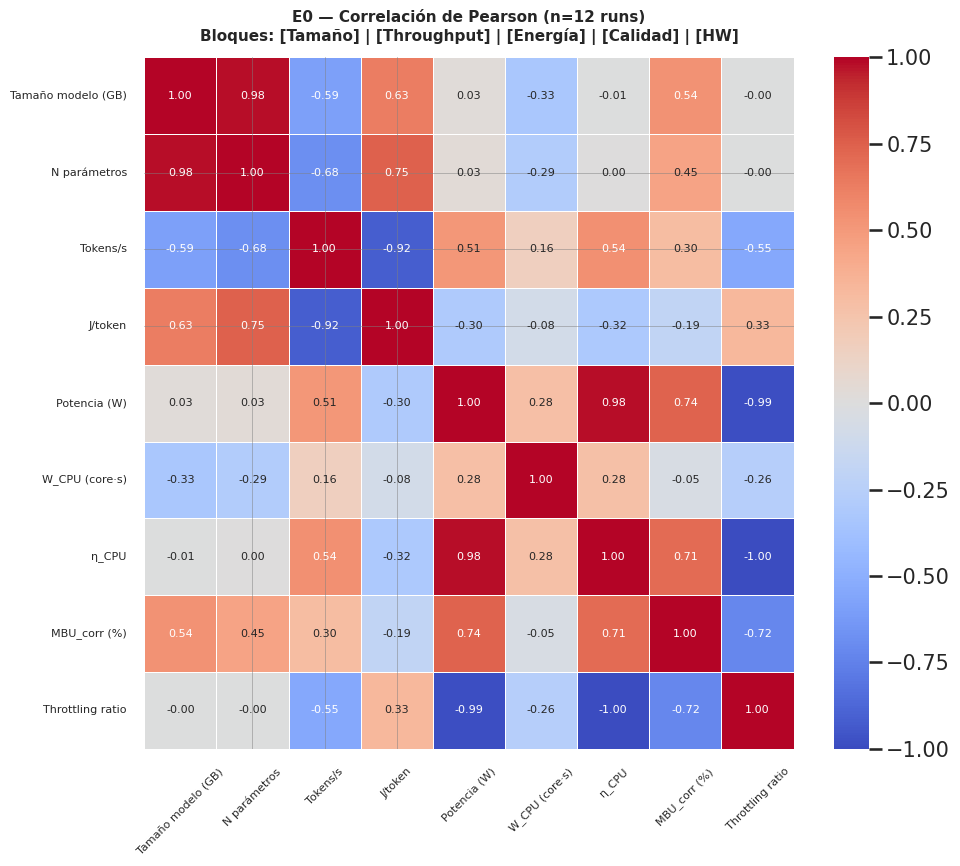

In [27]:
if not summary.empty and len(summary) >= 3:
    pearson_src = summary.copy()

    PEARSON_COLS_E0 = [
        "model_size_gb",
        "n_params",
        "tokens_per_s_mean",
        "latency_ms",
        "time_to_first_token_ms",
        "tokens_per_joule",
        "energy_per_token_j",
        "perplexity",
        "power_mean_w",
        "temp_max",
        "cpu_work_core_s",
        "cpu_efficiency",
        "mbu_corr",
        "throttled_ratio",
    ]
    available = [c for c in PEARSON_COLS_E0
                 if c in pearson_src.columns
                 and pd.api.types.is_numeric_dtype(pearson_src[c])]

    PEARSON_LABELS_E0 = {
        "model_size_gb":          "Tamaño modelo (GB)",
        "n_params":               "N parámetros",
        "tokens_per_s_mean":      "Tokens/s",
        "latency_ms":             "Latencia (ms)",
        "time_to_first_token_ms": "TTFT (ms)",
        "tokens_per_joule":       "tok/J",
        "energy_per_token_j":     "J/token",
        "perplexity":             "Perplejidad",
        "power_mean_w":           "Potencia (W)",
        "temp_max":               "Temp. máx (°C)",
        "cpu_work_core_s":        "W_CPU (core·s)",
        "cpu_efficiency":         "η_CPU",
        "mbu_corr":               "MBU_corr (%)",
        "throttled_ratio":        "Throttling ratio",
    }

    corr_df = (pearson_src[available]
               .dropna(how="all")
               .corr(numeric_only=True))
    corr_df = corr_df.rename(index=PEARSON_LABELS_E0, columns=PEARSON_LABELS_E0)
    n_vars  = len(corr_df)

    block_ends = []
    cumul = 0
    for group in [
        ["Tamaño modelo (GB)", "N parámetros"],
        ["Tokens/s", "Latencia (ms)", "TTFT (ms)"],
        ["tok/J", "J/token"],
        ["Perplejidad"],
        ["Potencia (W)", "Temp. máx (°C)", "W_CPU (core·s)", "η_CPU", "MBU_corr (%)", "Throttling ratio"],
    ]:
        count = sum(1 for g in group if g in corr_df.columns)
        cumul += count
        if count and cumul < n_vars:
            block_ends.append(cumul - 0.5)

    fig_sz  = max(10, n_vars * 0.85)
    fig, ax = plt.subplots(figsize=(fig_sz, fig_sz * 0.9))
    mask    = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
    sns.heatmap(
        corr_df,  annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        linewidths=0.4, ax=ax, annot_kws={"size": 8},
    )
    for d in block_ends:
        ax.axhline(d, color="gray", lw=0.7, alpha=0.5)
        ax.axvline(d, color="gray", lw=0.7, alpha=0.5)
    ax.set_title(
        f"E0 — Correlación de Pearson (n={len(summary)} runs)\n"
        "Bloques: [Tamaño] | [Throughput] | [Energía] | [Calidad] | [HW]",
        fontsize=11, pad=12,
    )
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    plt.tight_layout()
    plt.show()
else:
    n = len(summary) if not summary.empty else 0
    print(f"Se requieren ≥3 runs para la correlación (hay {n}).")


## 9. Análisis específico: impacto de la refrigeración activa

Comparativa directa entre los runs con ventilador (FAN) y sin ventilador
(NOFAN) para cada modelo. La refrigeración activa debería reducir el
throttling térmico y mejorar el throughput sostenido.

In [28]:
if not summary.empty and 'fan' in summary.columns:
    fan_cols = [c for c in ['tokens_per_s_mean', 'temp_max_c',
                              'throttled_ratio', 'cpu_efficiency']
                if c in summary.columns]
    if fan_cols:
        pivot = summary.pivot_table(
            index='model_label', columns='fan',
            values=fan_cols, aggfunc='mean'
        ).round(2)
        print('Fan (True) vs No-fan (False) por modelo:')
        display(pivot)
    else:
        print('Sin métricas disponibles para comparativa fan/nofan.')
else:
    print('Sin columna fan en summary.')


Fan (True) vs No-fan (False) por modelo:


cpu_efficiency       temp_max_c        throttled_ratio       tokens_per_s_mean       
fan                           False True       False  True            False True              False  True 
model_label                                                                                               
DeepSeek-R1-1.5B (L)           0.34  0.97      96.35  75.45             1.0   0.0              4.25   8.98
Llama-3.2-1B (L)               0.44  0.98      93.05  69.95             1.0   0.0              7.24  11.23
Llama-3.2-3B (L)               0.45  0.99      93.05  73.25             1.0   0.0              2.60   4.61
gemma (L)                      0.40  0.95      95.80  72.15             1.0   0.0              3.07   5.68
granite (L)                    0.42  0.97      95.80  69.40             1.0   0.0              2.88   4.41
ministral (L)                  0.43  0.98      93.60  73.25             1.0   0.0              2.71   4.73

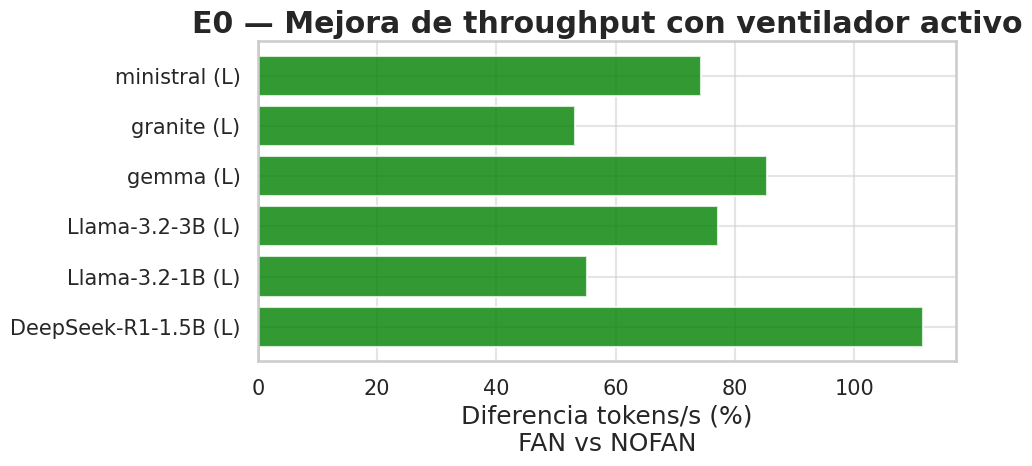


Diferencia absoluta y porcentual (FAN vs NOFAN):


,diff_tok_s,diff_pct
model_label,,
DeepSeek-R1-1.5B (L),4.733,111.5
Llama-3.2-1B (L),3.993,55.2
Llama-3.2-3B (L),2.006,77.1
gemma (L),2.616,85.3
granite (L),1.531,53.2
ministral (L),2.017,74.3


In [29]:
if (not summary.empty and 'fan' in summary.columns
        and 'tokens_per_s_mean' in summary.columns):
    fan_mean   = summary[summary['fan'] == True].groupby('model_label')['tokens_per_s_mean'].mean()
    nofan_mean = summary[summary['fan'] == False].groupby('model_label')['tokens_per_s_mean'].mean()
    common = fan_mean.index.intersection(nofan_mean.index)
    if len(common) > 0:
        diff     = fan_mean.loc[common] - nofan_mean.loc[common]
        diff_pct = diff / nofan_mean.loc[common] * 100
        fig, ax = plt.subplots(figsize=(10, 5))
        colors = ['green' if v > 0 else 'red' for v in diff_pct]
        ax.barh(common.tolist(), diff_pct.values, color=colors, alpha=0.8)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel('Diferencia tokens/s (%)\nFAN vs NOFAN')
        ax.set_title('E0 — Mejora de throughput con ventilador activo')
        ax.tick_params(axis='y', rotation=0)
        plt.tight_layout()
        plt.show()

        print('\nDiferencia absoluta y porcentual (FAN vs NOFAN):')
        display(pd.DataFrame({'diff_tok_s': diff.round(3), 'diff_pct': diff_pct.round(1)}))
    else:
        print('Sin modelos comunes entre FAN y NOFAN.')
else:
    print('Sin datos para comparativa fan/nofan.')

In [30]:
if not summary.empty and 'fan' in summary.columns:
    fan_summary = summary[summary['fan'] == True]
    if not fan_summary.empty:
        rank_cols = [c for c in ['model_label', 'tokens_per_s_mean',
                                   'energy_per_token_j', 'throttled_ratio']
                     if c in fan_summary.columns]
        if 'tokens_per_s_mean' in fan_summary.columns:
            ranking = (fan_summary[rank_cols]
                       .sort_values('tokens_per_s_mean', ascending=False)
                       .reset_index(drop=True))
            ranking.index += 1
            print('Ranking de modelos (con ventilador, por throughput):')
            display(ranking.round(3))
        else:
            print('tokens_per_s_mean no disponible para ranking.')
    else:
        print('Sin runs con ventilador (fan=True).')
else:
    print('Sin datos para ranking de modelos.')


Ranking de modelos (con ventilador, por throughput):


,model_label,tokens_per_s_mean,energy_per_token_j,throttled_ratio
1,Llama-3.2-1B (L),11.229,0.577,0.0
2,DeepSeek-R1-1.5B (L),8.978,0.799,0.0
3,gemma (L),5.683,1.214,0.0
4,ministral (L),4.731,1.440,0.0
5,Llama-3.2-3B (L),4.608,1.469,0.0
6,granite (L),4.410,1.519,0.0


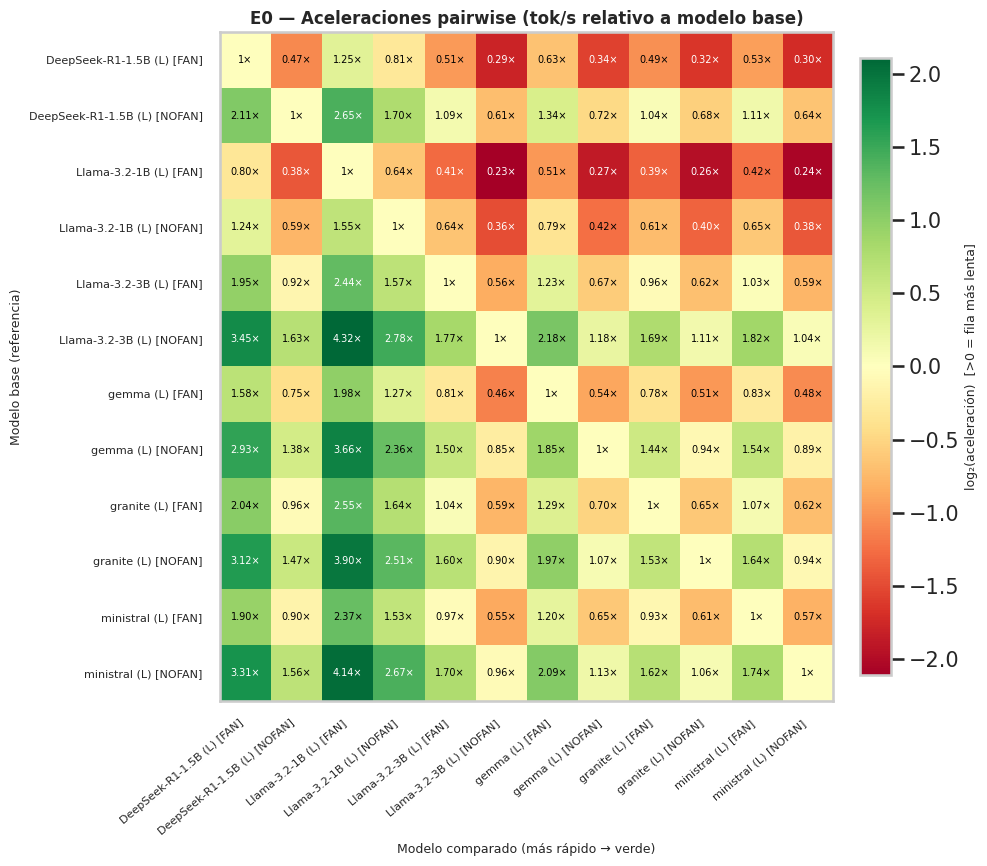

In [31]:
# Tabla de aceleraciones — comparación pairwise de todos los modelos (E0)
if not summary.empty and "tokens_per_s_mean" in summary.columns:
    _df_sp = summary.dropna(subset=["tokens_per_s_mean", "model_label"]).copy()

    # config_label: modelo + fan para distinguir FAN/NOFAN
    if "fan" in _df_sp.columns:
        _df_sp["_config"] = (_df_sp["model_label"]
                             + _df_sp["fan"].map({True: " [FAN]", False: " [NOFAN]"}).fillna(""))
    else:
        _df_sp["_config"] = _df_sp["model_label"]

    # Mediana por config si hay varios runs
    _speed = _df_sp.groupby("_config")["tokens_per_s_mean"].median()
    _labels = _speed.index.tolist()
    _n = len(_labels)

    _mat = np.zeros((_n, _n))
    for _i, _base in enumerate(_labels):
        for _j, _tgt in enumerate(_labels):
            _mat[_i, _j] = _speed[_tgt] / _speed[_base]

    _log_mat = np.log2(_mat)
    _off_diag = _log_mat[~np.eye(_n, dtype=bool)]
    _abs_max  = max(float(abs(_off_diag).max()), 0.5)

    fig, ax = plt.subplots(figsize=(max(9, _n * 0.85), max(8, _n * 0.75)))
    im = ax.imshow(_log_mat, cmap="RdYlGn", vmin=-_abs_max, vmax=_abs_max,
                   aspect="auto")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("log₂(aceleración)  [>0 = fila más lenta]", fontsize=9)

    ax.set_xticks(range(_n)); ax.set_yticks(range(_n))
    ax.set_xticklabels(_labels, rotation=40, ha="right", fontsize=8)
    ax.set_yticklabels(_labels, fontsize=8)
    ax.set_xlabel("Modelo comparado (más rápido → verde)", fontsize=9)
    ax.set_ylabel("Modelo base (referencia)", fontsize=9)
    ax.grid(False)

    for _i in range(_n):
        for _j in range(_n):
            _v  = _mat[_i, _j]
            _lv = _log_mat[_i, _j]
            _txt = "1×" if _i == _j else f"{_v:.2f}×"
            ax.text(_j, _i, _txt, ha="center", va="center", fontsize=7,
                    color="white" if abs(_lv) > _abs_max * 0.6 else "black")

    ax.set_title("E0 — Aceleraciones pairwise (tok/s relativo a modelo base)",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para tabla de aceleraciones")


## Figura de Mérito (FoM_full)

Combina cuatro ejes normalizados respecto a la configuración de referencia
(**llama3.2:3b · llama.cpp · Q4_K_M · ctx=4096 · bs=512**):

$$\text{FoM\_full} = \bigl(T_{norm} \cdot MBU_{norm} \cdot \eta_{norm} \cdot \varepsilon_{norm}\bigr)^{1/4}$$

| Eje | Normalización | Significado |
|-----|--------------|-------------|
| $T_{norm}$ | $N \cdot T / (N_{ref} T_{ref})$ | Throughput ponderado por tamaño |
| $MBU_{norm}$ | $\text{MBU\_corr} / \text{MBU}_{ref}$ | Utilización de ancho de banda (corregida) |
| $\eta_{norm}$ | $\eta_{CPU} / \eta_{ref}$ | Eficiencia computacional |
| $\varepsilon_{norm}$ | $N \cdot \varepsilon / (N_{ref} \varepsilon_{ref})$ | Tokens/J ponderados por tamaño |

**FoM_full > 1** → la configuración supera a la referencia en media geométrica.


In [32]:
# ── FoM_full — Figura de Mérito compuesta (E0) ─────────────────────────────
from monitorviz.transforms.fom import compute_fom_full, compute_usability

_pm = (pm_full if "pm_full" in dir() else
       pm_df   if "pm_df"   in dir() else pd.DataFrame())
_FOM_AXES = {
    "fom_T_norm":   r"$T_{norm}$ (N·tok/s)",
    "fom_MBU_norm": r"$MBU_{norm}$",
    "fom_eta_norm": r"$\eta_{norm}$",
    "fom_eps_norm": r"$\varepsilon_{norm}$ (N·tok/J)",
    "fom_full":     "FoM_full",
}
_x_col = "config_label" if "config_label" in summary.columns else "model_label"
_hue   = "fan" if "fan" in summary.columns else None

try:
    fom_df = compute_fom_full(summary)
    avail = [c for c in _FOM_AXES if c in fom_df.columns and fom_df[c].notna().any()]
    if avail:
        fig, plot_axes = plt.subplots(1, len(avail), figsize=(3.5 * len(avail), 5))
        if len(avail) == 1:
            plot_axes = [plot_axes]
        for ax, col in zip(plot_axes, avail):
            d = fom_df.dropna(subset=[col])
            kw = dict(data=d, x=_x_col, y=col, ax=ax)
            if _hue and _hue in d.columns:
                kw["hue"] = _hue
            sns.barplot(**kw)
            ax.set_title(_FOM_AXES[col], fontsize=10)
            ax.set_xlabel("")
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
            ax.axhline(1.0, ls="--", color="gray", alpha=0.5)
            if _hue:
                ax.legend(fontsize=7)
        fig.suptitle("E0 — Figura de Mérito (FoM_full)", fontsize=12)
        fig.tight_layout()
        plt.show()
        _disp = [c for c in [_x_col, _hue, "mbu_corr", "tokens_per_s_mean", "fom_full"]
                 if c and c in fom_df.columns]
        print("FoM_full por configuración:")
        display(fom_df[_disp].round(3))
    if not _pm.empty:
        fom_df, _tpw = compute_usability(fom_df, _pm)
        n_usable = int(fom_df["usable"].sum()) if "usable" in fom_df.columns else 0
        print(f"\nCriterio de usabilidad (≥3 palabras/s): {n_usable}/{len(fom_df)} runs usables")
        _uc = [c for c in [_x_col, "tokens_per_s_mean", "T_hum", "usable"] if c in fom_df.columns]
        if _uc:
            display(fom_df[_uc].round(3))
except Exception as e:
    print(f"Error en FoM: {e}")



Criterio de usabilidad (≥3 palabras/s): 8/12 runs usables


,config_label,tokens_per_s_mean,T_hum,usable
0,ministral (L)\n(FAN),4.731,4.522,True
1,Llama-3.2-3B (L)\n(FAN),4.608,4.252,True
2,Llama-3.2-1B (L)\n(FAN),11.229,4.416,True
3,granite (L)\n(FAN),4.410,3.987,True
4,gemma (L)\n(FAN),5.683,4.449,True
5,DeepSeek-R1-1.5B (L)\n(FAN),8.978,3.691,True
6,ministral (L)\n(NOFAN),2.714,4.522,False
7,Llama-3.2-3B (L)\n(NOFAN),2.602,4.252,False
8,Llama-3.2-1B (L)\n(NOFAN),7.236,4.416,True
9,granite (L)\n(NOFAN),2.879,3.987,False


## 10. Conclusiones y discusión

### Confirmación de hipótesis
> [Rellenar con los resultados reales una vez ejecutado el notebook]

### Hallazgos principales
1. ...
2. ...
3. ...

### Limitaciones
- El análisis energético no incluye el consumo del sistema de refrigeración.
- La métrica MBU es una cota superior teórica para gemma3n (activación selectiva). En el caso de Granite no se dispone de  la caché kv
- Los prompts de IFEval pueden favorecer ciertos tipos de respuesta.

### Próximos pasos
- Comparar con los resultados del experimento E4 (OLLAMA vs LLAMA.cpp).
- Analizar el impacto de la cuantización en E1.